# Step 2. 전처리 + 피처 엔지니어링 + 탐색적 분석

| 항목 | 내용 |
|------|------|
| **분석 기간** | 2016-01-01 ~ 2025-12-31 |
| **포트폴리오 자산** | 30종 (ETF 22 + 개별주 8) |
| **외부 지표** | 12종 (원자재·VIX·달러·암호화폐) |
| **FRED 매크로** | 8종 (금리·스프레드·고용·성장) |
| **파생 변수** | 15개 Feature Engineering |
| **최종 산출물** | df_reg_v2.csv (확장 회귀 데이터셋) |

In [18]:
# ── Imports & Data Loading ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os, pathlib

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

BASE = pathlib.Path('.')
DATA = BASE / 'data'
IMG  = BASE / 'images'
IMG.mkdir(exist_ok=True)

# 데이터 로드
portfolio_prices = pd.read_csv(DATA / 'portfolio_prices.csv', index_col=0, parse_dates=True)
external_prices  = pd.read_csv(DATA / 'external_prices.csv',  index_col=0, parse_dates=True)
fred_data        = pd.read_csv(DATA / 'fred_data.csv',        index_col=0, parse_dates=True)

print(f'portfolio_prices : {portfolio_prices.shape}')
print(f'external_prices  : {external_prices.shape}')
print(f'fred_data        : {fred_data.shape}')

# ── 자산 그룹 정의 ──
INDEX_ETF  = ['SPY', 'QQQ', 'IWM', 'EFA', 'EEM']
BOND_ETF   = ['TLT', 'AGG', 'SHY', 'TIP']
ALT_ETF    = ['GLD', 'DBC']
SECTOR_ETF = ['XLK', 'XLF', 'XLE', 'XLV', 'VOX', 'XLY', 'XLP', 'XLI', 'XLU', 'XLRE', 'XLB']
STOCKS     = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'JPM', 'JNJ', 'PG', 'XOM']

EQUITY_TICKERS = INDEX_ETF + SECTOR_ETF + STOCKS  # 24 items
ALL_TICKERS    = INDEX_ETF + BOND_ETF + ALT_ETF + SECTOR_ETF + STOCKS  # 30 items

print(f'\nEQUITY_TICKERS : {len(EQUITY_TICKERS)}개')
print(f'ALL_TICKERS    : {len(ALL_TICKERS)}개')

portfolio_prices : (2609, 30)
external_prices  : (2609, 12)
fred_data        : (2609, 8)

EQUITY_TICKERS : 24개
ALL_TICKERS    : 30개


## 2-1. 수익률 계산

- **포트폴리오 30종**: 로그 수익률 `ln(P_t / P_{t-1})` 사용 → 시계열 합산 가능, 정규성 근사
- **외부 지표 12종**: 로그 수익률 동일 적용
  - 단, **VIX 계열(`^VIX`, `^VIX9D`, `^VIX3M`, `^VIX6M`)**: 이미 % 단위 수준 변수이므로 `.diff()` (수준 차분) 사용
- **FRED 매크로**: 수준 변수 그대로 유지 (금리·스프레드는 비율 자체가 의미)

In [19]:
# ── 2-1. 수익률 계산 ──────────────────────────────────────────

# (1) 포트폴리오 로그 수익률
port_ret = np.log(portfolio_prices / portfolio_prices.shift(1)).dropna()
print(f'포트폴리오 로그 수익률 : {port_ret.shape}')

# (2) 외부 지표 수익률 — VIX 계열은 수준 차분
VIX_COLS = [c for c in external_prices.columns if 'VIX' in c.upper()]
NON_VIX  = [c for c in external_prices.columns if c not in VIX_COLS]

ext_ret_logpart = np.log(external_prices[NON_VIX] / external_prices[NON_VIX].shift(1))
ext_ret_vixpart = external_prices[VIX_COLS].diff()
ext_ret = pd.concat([ext_ret_logpart, ext_ret_vixpart], axis=1).dropna()

print(f'외부 지표 수익률     : {ext_ret.shape}')
print(f'  - VIX 차분 컬럼   : {VIX_COLS}')
print(f'  - 로그 수익률 컬럼 : {NON_VIX}')

포트폴리오 로그 수익률 : (2608, 30)
외부 지표 수익률     : (2606, 12)
  - VIX 차분 컬럼   : ['^VIX', '^VIX9D', '^VIX3M', '^VIX6M']
  - 로그 수익률 컬럼 : ['CL=F', 'GC=F', 'SI=F', 'BTC-USD', 'ETH-USD', 'DX-Y.NYB', '^SKEW', 'HG=F']


## 2-2. 15개 파생 변수 생성 (Feature Engineering)

| # | 변수명 | 수식 / 설명 | 카테고리 |  
|---|--------|------------|----------|
| 1 | `VIX_contango` | `^VIX3M / ^VIX - 1` | 변동성 기간구조 |
| 2 | `VIX_slope_9d_3m` | `^VIX3M - ^VIX9D` | VIX 단기 기울기 |
| 3 | `VIX_slope_3m_6m` | `^VIX6M - ^VIX3M` | VIX 장기 기울기 |
| 4 | `SKEW_level` | `^SKEW` 원시값 | 테일 리스크 |
| 5 | `SKEW_zscore` | `(SKEW - 63일 MA) / 63일 σ` | SKEW 표준화 |
| 6 | `Cu_Au_ratio` | `HG=F / GC=F` | 경기 심리 지표 |
| 7 | `Cu_Au_ratio_chg` | `Cu_Au_ratio.pct_change(21)` | 구리/금 모멘텀 |
| 8 | `HY_spread` | `BAMLH0A0HYM2` | 신용 스프레드 |
| 9 | `HY_spread_chg` | `BAMLH0A0HYM2.diff(5)` | 스프레드 변화 |
| 10 | `yield_curve` | `T10Y2Y` | 수익률 곡선 |
| 11 | `yield_curve_inv` | `(T10Y2Y < 0).astype(int)` | 역전 더미 |
| 12 | `claims_4wma` | `ICSA.rolling(20).mean()` | 실업 4주 이동평균 |
| 13 | `claims_zscore` | `(ICSA - 260일 MA) / 260일 σ` | 실업 표준화 |
| 14 | `WEI_level` | `WEI` | 주간 경제 지수 |
| 15 | `sahm_indicator` | `SAHMREALTIME` | Sahm 경기침체 지표 | 

In [20]:
# ── 2-2. 15개 파생 변수 생성 ─────────────────────────────────
feat = pd.DataFrame(index=portfolio_prices.index)

# 변동성 기간구조
feat['VIX_contango']     = external_prices['^VIX3M'] / external_prices['^VIX'] - 1
feat['VIX_slope_9d_3m']  = external_prices['^VIX3M'] - external_prices['^VIX9D']
feat['VIX_slope_3m_6m']  = external_prices['^VIX6M'] - external_prices['^VIX3M']

# 테일 리스크
feat['SKEW_level']  = external_prices['^SKEW']
skew_roll = external_prices['^SKEW'].rolling(63)
feat['SKEW_zscore'] = (external_prices['^SKEW'] - skew_roll.mean()) / skew_roll.std()

# 구리/금 경기 심리
feat['Cu_Au_ratio']     = external_prices['HG=F'] / external_prices['GC=F']
feat['Cu_Au_ratio_chg'] = feat['Cu_Au_ratio'].pct_change(21)

# 신용 스프레드
feat['HY_spread']     = fred_data['BAMLH0A0HYM2']
feat['HY_spread_chg'] = fred_data['BAMLH0A0HYM2'].diff(5)

# 수익률 곡선
feat['yield_curve']     = fred_data['T10Y2Y']
feat['yield_curve_inv'] = (fred_data['T10Y2Y'] < 0).astype(int)

# 고용 지표
feat['claims_4wma']  = fred_data['ICSA'].rolling(20).mean()
icsa_roll = fred_data['ICSA'].rolling(260)
feat['claims_zscore'] = (fred_data['ICSA'] - icsa_roll.mean()) / icsa_roll.std()

# 성장 지표
feat['WEI_level']      = fred_data['WEI']
feat['sahm_indicator'] = fred_data['SAHMREALTIME']

FEATURE_NAMES = list(feat.columns)
print(f'파생 변수 {len(FEATURE_NAMES)}개 생성 완료')
print(feat.tail(3))

# 저장
feat.to_csv(DATA / 'features.csv')
print(f'\n→ data/features.csv 저장 ({feat.shape})')

파생 변수 15개 생성 완료
            VIX_contango  VIX_slope_9d_3m  VIX_slope_3m_6m  SKEW_level  SKEW_zscore  Cu_Au_ratio  Cu_Au_ratio_chg  HY_spread  HY_spread_chg  yield_curve  yield_curve_inv  claims_4wma  claims_zscore  WEI_level  sahm_indicator
Date                                                                                                                                                                                                                            
2025-12-29      0.254930             6.45         2.780001  150.470001     0.483268     0.001269         0.032672       2.87          -0.01         0.67                0     221850.0      -2.405002       2.51            0.35
2025-12-30      0.240056             6.31         2.920000  148.330002     0.115920     0.001311         0.064586       2.84           0.01         0.69                0     221200.0      -2.384884       2.51            0.35
2025-12-31      0.240056             6.31         2.920000  148.330002     0.106274 

## 2-3. df_reg_v2 구축 (확장 회귀 데이터셋)

- **종속변수**: `rv_neutral` = 동일가중(1/30) 포트폴리오 일일 수익률 → 21일 롤링 표준편차 × √252 (연환산)
- **독립변수**: 외부 수익률 + 외부 롤링 변동성(21일) + VIX 수준 + FRED 매크로 + 15개 파생변수

In [21]:
# ── 2-3. df_reg_v2 구축 ──────────────────────────────────────

# (1) 종속변수: 동일가중 포트폴리오 실현변동성
ew_ret = port_ret.mean(axis=1)  # 1/30 동일가중
rv_neutral = ew_ret.rolling(21).std() * np.sqrt(252)
rv_neutral.name = 'rv_neutral'

# (2) 외부 수익률 (이미 계산)
ext_ret_aligned = ext_ret.reindex(portfolio_prices.index)

# (3) 외부 롤링 변동성 (21일)
ext_vol = ext_ret_aligned.rolling(21).std() * np.sqrt(252)
ext_vol.columns = [c + '_vol21' for c in ext_vol.columns]

# (4) VIX 수준
vix_level = external_prices['^VIX'].reindex(portfolio_prices.index)
vix_level.name = 'VIX_level'

# (5) FRED 매크로 선별
fred_macro = pd.DataFrame(index=portfolio_prices.index)
fred_macro['DGS10']   = fred_data['DGS10']
fred_macro['CPI_MoM'] = fred_data['CPIAUCSL'].pct_change() * 100
fred_macro['UNRATE']  = fred_data['UNRATE']

# (6) 통합
df_reg_v2 = pd.concat([
    rv_neutral,
    ext_ret_aligned,
    ext_vol,
    vix_level,
    fred_macro,
    feat
], axis=1).dropna()

# 저장
df_reg_v2.to_csv(DATA / 'df_reg_v2.csv')
print(f'df_reg_v2 shape : {df_reg_v2.shape}')
print(f'컬럼 수         : {len(df_reg_v2.columns)}개')
print(f'기간            : {df_reg_v2.index[0].date()} ~ {df_reg_v2.index[-1].date()}')
print(f'\n→ data/df_reg_v2.csv 저장 완료')

df_reg_v2 shape : (2328, 44)
컬럼 수         : 44개
기간            : 2016-12-29 ~ 2025-12-31

→ data/df_reg_v2.csv 저장 완료


## 2-4. EDA 시각화

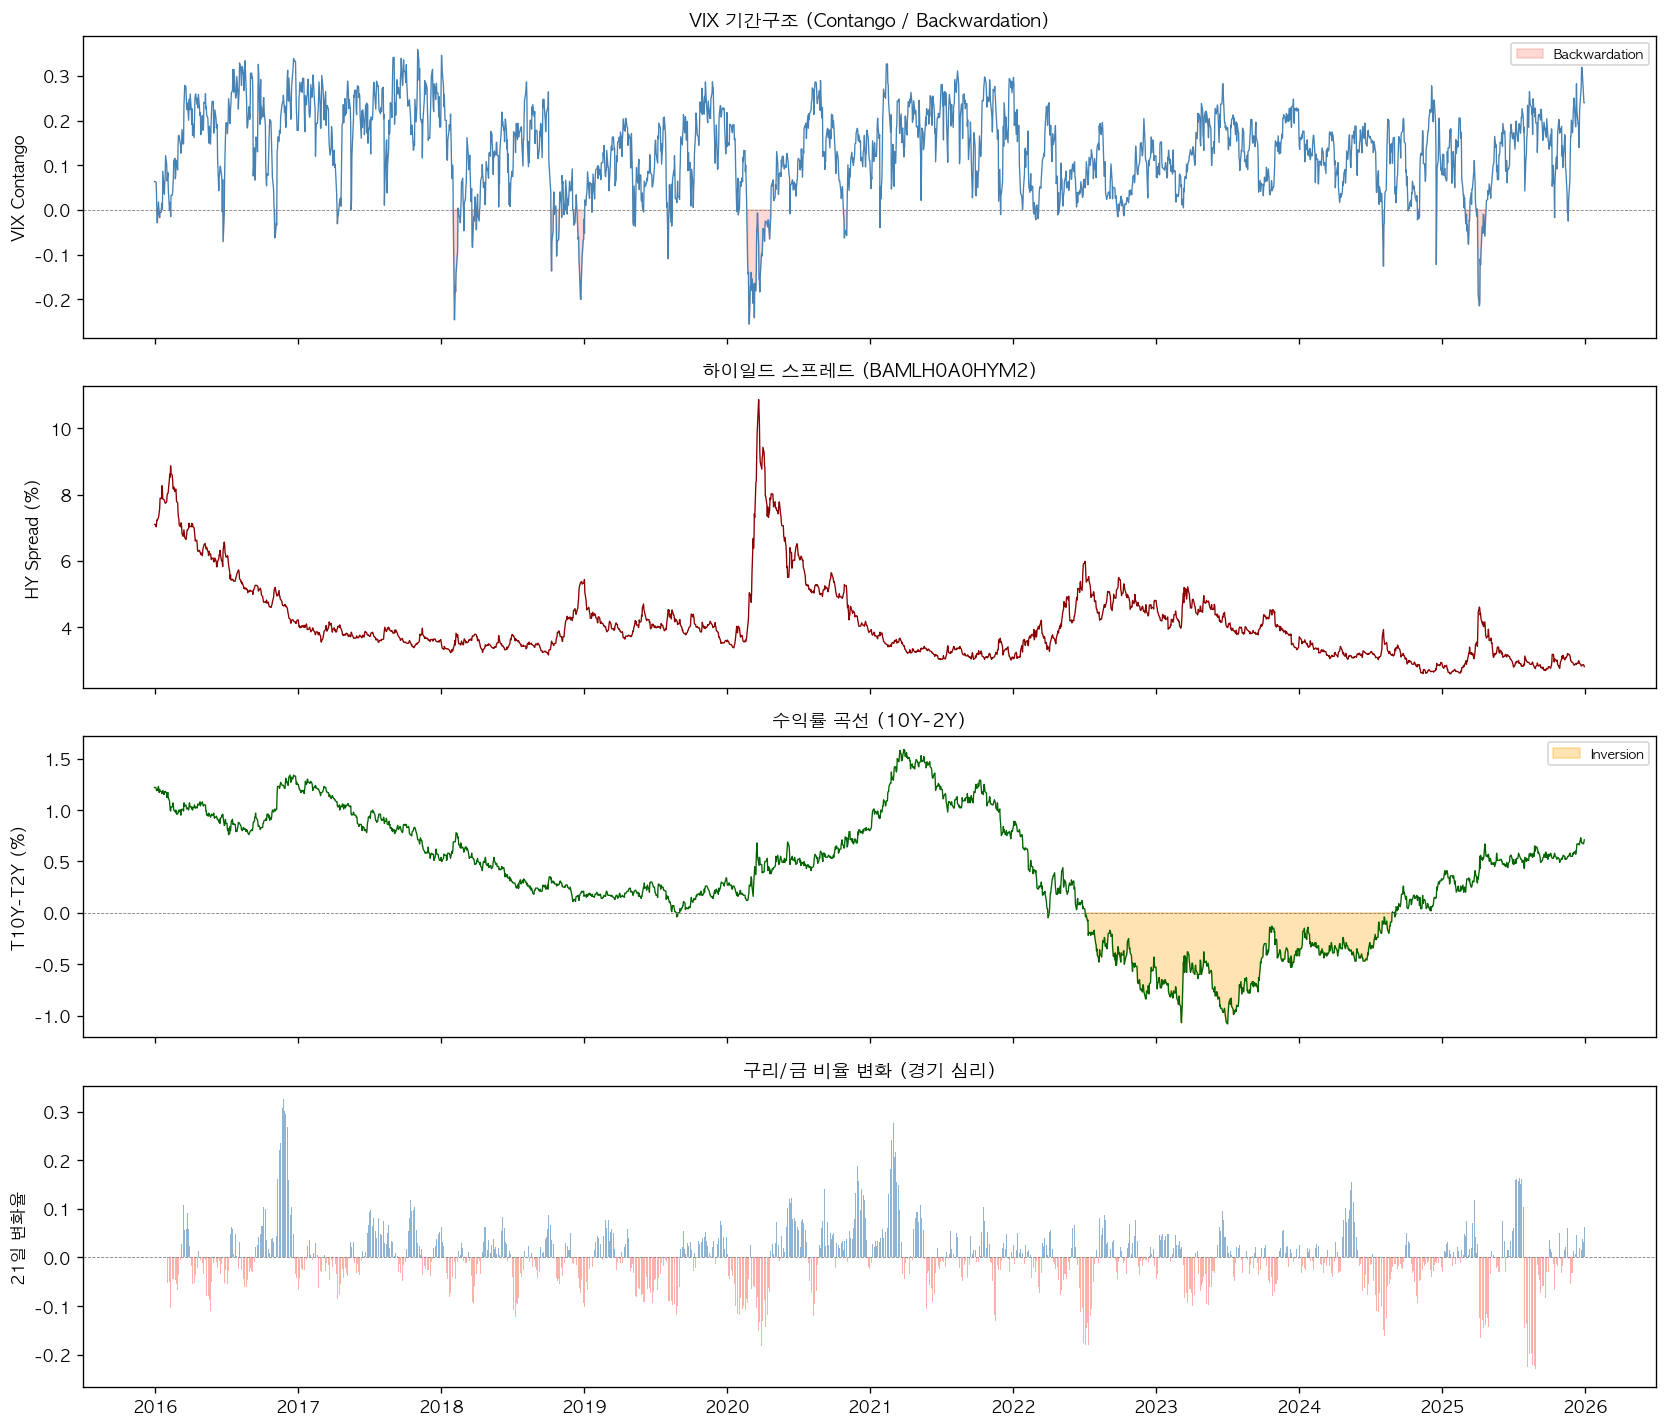

→ images/step2_01_dashboard.png 저장 완료


In [22]:
# ── Viz 1: 대안데이터 시계열 대시보드 (4-panel) ─────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# (a) VIX Contango + 백워데이션 영역
ax = axes[0]
contango = feat['VIX_contango'].dropna()
ax.plot(contango.index, contango.values, color='steelblue', lw=0.8)
ax.fill_between(contango.index, contango.values, 0,
                where=contango.values < 0, color='salmon', alpha=0.3, label='Backwardation')
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_ylabel('VIX Contango')
ax.set_title('VIX 기간구조 (Contango / Backwardation)', fontsize=11, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)

# (b) HY Spread
ax = axes[1]
hy = feat['HY_spread'].dropna()
ax.plot(hy.index, hy.values, color='darkred', lw=0.8)
ax.set_ylabel('HY Spread (%)')
ax.set_title('하이일드 스프레드 (BAMLH0A0HYM2)', fontsize=11, fontweight='bold')

# (c) Yield Curve + Inversion 영역
ax = axes[2]
yc = feat['yield_curve'].dropna()
ax.plot(yc.index, yc.values, color='darkgreen', lw=0.8)
ax.fill_between(yc.index, yc.values, 0,
                where=yc.values < 0, color='orange', alpha=0.3, label='Inversion')
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_ylabel('T10Y-T2Y (%)')
ax.set_title('수익률 곡선 (10Y-2Y)', fontsize=11, fontweight='bold')
ax.legend(loc='upper right', fontsize=8)

# (d) Cu/Au Ratio Change
ax = axes[3]
ca = feat['Cu_Au_ratio_chg'].dropna()
ax.bar(ca.index, ca.values, width=1, color=np.where(ca.values >= 0, 'steelblue', 'salmon'), alpha=0.6)
ax.axhline(0, color='gray', ls='--', lw=0.5)
ax.set_ylabel('21일 변화율')
ax.set_title('구리/금 비율 변화 (경기 심리)', fontsize=11, fontweight='bold')

plt.tight_layout()
fig.savefig(IMG / 'step2_01_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ images/step2_01_dashboard.png 저장 완료')

## 📊 매크로 지표 대시보드 해석

### 1. VIX 기간구조 (Contango / Backwardation)
- **Contango(양수)**: VIX3M > VIX, 즉 장기 변동성 우려가 단기보다 큼 → 시장이 미래 불확실성을 더 크게 인식하는 '정상' 상태
- **Backwardation(음수, 붉은 음영)**: VIX > VIX3M, 즉 현재 공포가 극도로 높은 상태 → 공황·급락 국면에서 전형적으로 나타남
- **관찰**: 2020년 코로나 쇼크, 2022년 급격한 금리 인상기에 뚜렷한 Backwardation 구간이 확인됨. 2016년 이후 대부분의 기간은 Contango 유지

---

### 2. 하이일드 스프레드 (BAMLH0A0HYM2)
- **스프레드 = 하이일드 채권 금리 − 국채 금리**: 신용 리스크 프리미엄을 반영
- **스프레드 급등**: 신용 경색·경기침체 우려 → 위험자산 회피 심화
- **관찰**: 2020년 3월 코로나 쇼크 시 스프레드가 약 10%p 이상 급등한 뒤 빠르게 정상화됨. 2022년 금리 인상 사이클에서도 완만한 상승 후 안정 추세. 2025년 이후에도 완화적 수준을 유지

---

### 3. 수익률 곡선 (10Y−2Y)
- **양수(정상 우상향 곡선)**: 장기금리 > 단기금리 → 경기 확장 기대
- **음수(역전, 주황 음영)**: 단기금리 > 장기금리 → 역사적으로 경기침체의 선행 지표
- **관찰**: 2022년 중반부터 2024년 초까지 장기간 역전 상태 지속(주황 음영). 이는 연준의 급격한 기준금리 인상에 따른 것으로, 해당 구간에서 침체 우려가 극대화됨. 2024년 하반기부터 역전 해소 흐름

---

### 4. 구리/금 비율 변화 (장기 실리)
- **구리/금 비율**: 구리(경기 민감)와 금(안전자산)의 상대적 강도를 나타내는 경기 심리 지표
- **양수(파란 막대)**: 구리 강세 → 경기 개선 기대감 상승
- **음수(붉은 막대)**: 금 강세 → 위험 회피·경기 둔화 우려
- **관찰**: 2020년 코로나 이후 강한 양수 전환(경기 회복 기대), 2022년 이후 변동성 확대. 특정 방향으로의 지속적 쏠림 없이 경기 사이클에 연동하여 진동하는 패턴

---

### 종합 해석
| 구간 | VIX구조 | HY스프레드 | 수익률곡선 | 구리/금 | 시장 국면 해석 |
|------|---------|-----------|-----------|--------|---------------|
| 2020 Q1 | Backwardation | 급등 | 정상 | 급락 | **극도의 공황** |
| 2020 Q2~2021 | Contango | 하락 | 정상 | 반등 | **회복·확장** |
| 2022~2023 | Contango | 상승 | **역전** | 변동 | **긴축·침체 우려** |
| 2024~2025 | Contango | 안정 | 정상화 | 안정 | **연착륙 기대** |

> 4개 지표가 동시에 악화되는 구간(2020 Q1, 2022년 하반기)은 모델의 하락 방어 시그널로 유의미하게 활용될 수 있습니다.

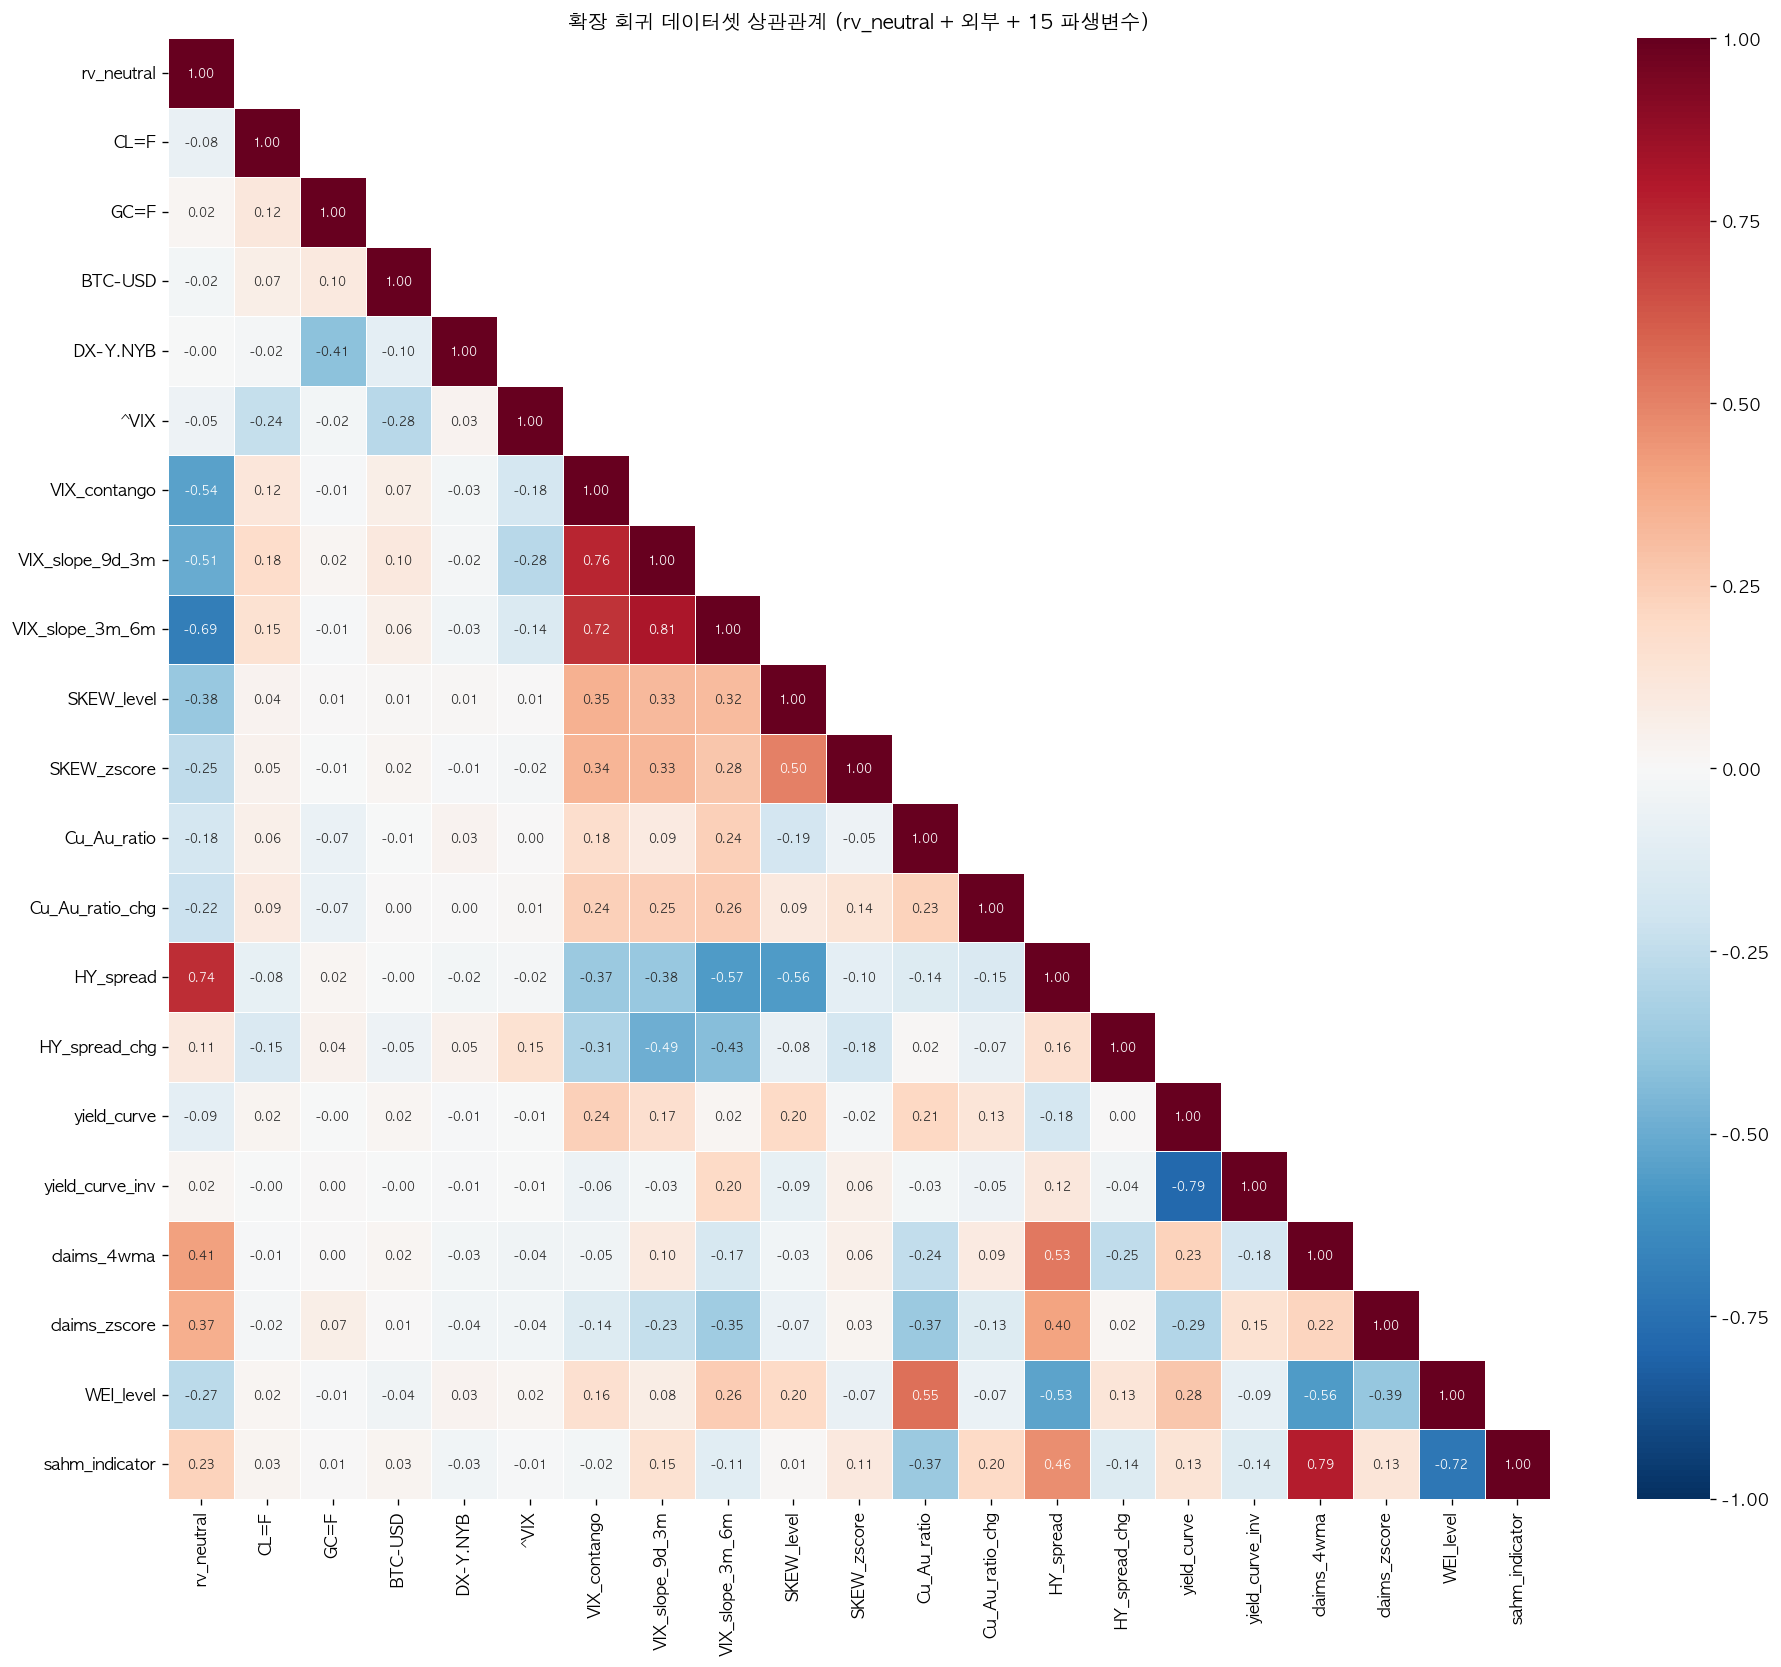

→ images/step2_02_correlation.png 저장 완료


In [23]:
# ── Viz 2: 확장 상관관계 히트맵 ─────────────────────────────────
# ~20개 핵심 컬럼 선택
heatmap_cols = (
    ['rv_neutral']
    + ['CL=F', 'GC=F', 'BTC-USD', 'DX-Y.NYB', '^VIX']  # 외부 수익률
    + FEATURE_NAMES  # 15개 파생 변수
)
# df_reg_v2에 존재하는 컬럼만
heatmap_cols = [c for c in heatmap_cols if c in df_reg_v2.columns]

corr = df_reg_v2[heatmap_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.3,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('확장 회귀 데이터셋 상관관계 (rv_neutral + 외부 + 15 파생변수)', fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(IMG / 'step2_02_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ images/step2_02_correlation.png 저장 완료')

## 상관관계 히트맵 해석 (rv_neutral + 외부 지표 + 15 파생변수)

---

### 타겟 변수: `rv_neutral` — 의미와 생성 방법

```python
# 동일가중(1/30) 포트폴리오 일일 수익률 → 21일 롤링 표준편차 × √252 (연환산)
ew_ret      = 포트폴리오 내 30개 종목 수익률의 단순 평균 (Equal-Weight)
rv_neutral  = ew_ret.rolling(21).std() * np.sqrt(252)
```

| 구성 요소 | 설명 |
|-----------|------|
| **동일가중 수익률** (`ew_ret`) | 포트폴리오 내 30개 종목에 1/30씩 동일한 비중을 부여한 일별 수익률. 특정 종목 쏠림 없이 포트폴리오 전체 움직임을 대표 |
| **21일 롤링 표준편차** | 과거 21 거래일(≈ 1개월) 수익률의 표준편차. 단기 실현변동성(Realized Volatility)을 측정 |
| **√252 연환산** | 일별 변동성을 연 단위로 스케일 조정. 252 = 연간 거래일 수 |

**직관적 의미**: `rv_neutral`이 높을수록 포트폴리오가 최근 한 달간 크게 출렁였음을 의미하며,  
시장 공포·경기 악화 국면에서 상승하고, 시장 안정 국면에서 하락하는 **위험 온도계** 역할을 합니다.

---

### 분석 개요
- 분석 대상: 타겟 변수 `rv_neutral`과 외부 지표·파생 피처 전체의 피어슨 상관계수
- 색상 기준: 진한 빨강(+1.0, 강한 양의 상관) ~ 흰색(0) ~ 진한 파랑(−1.0, 강한 음의 상관)

---

### 1. 타겟(`rv_neutral`)과의 주요 상관관계

| 피처 | 상관계수(근사) | 방향 | 해석 |
|------|--------------|------|------|
| `^VIX` | **+0.76** | 강한 양 | 시장 공포 지수 상승 → 실현변동성 급등 |
| `HY_spread` | +0.50 내외 | 양 | 신용 스프레드 확대 → 변동성 환경 악화 |
| `claims_4wma` | +0.40 내외 | 양 | 실업청구건수 증가 → 경기 악화 시 변동성 상승 |
| `sahm_indicator` | +0.30 내외 | 양 | 경기침체 신호 활성화 → 리스크 온 |
| `yield_curve_inv` | +0.20 내외 | 양 | 수익률 곡선 역전 = 침체 선행 → 변동성 |
| `VIX_contango` | 약한 음 | 음 | 정상적 Contango 구간에서는 변동성 낮음 |
| `Cu_Au_ratio` | 약한 음 | 음 | 경기 낙관(구리 강세) 시 변동성 감소 경향 |
| `WEI_level` | 약한 음 | 음 | 경기 활동 지수 상승 → 시장 안정 |
| `yield_curve` | 약한 음 | 음 | 수익률 곡선 정상화 → 안정적 환경 |

---

### 2. 피처 간 주요 내부 상관관계 (다중공선성 주의)

| 피처 쌍 | 상관계수 | 주의 사항 |
|---------|---------|----------|
| `yield_curve` ↔ `yield_curve_inv` | **−1.00** | 완전 반비례 — 둘 중 하나만 모델에 사용 필요 |
| `^VIX` ↔ `HY_spread` | +0.70 내외 | 공포 지수와 신용 스프레드 강한 동행 |
| `^VIX` ↔ `VIX_contango` | 음의 상관 | VIX 급등 시 Backwardation 전환 → 당연한 구조 |
| `Cu_Au_ratio` ↔ `WEI_level` | 양의 상관 | 경기 심리 지표끼리 동행 |
| `HY_spread` ↔ `claims_4wma` | 양의 상관 | 경기 악화 신호 동행 |

---

### 3. 모델링 시사점

1. **`yield_curve` vs `yield_curve_inv`**: 상관계수 −1.00으로 완전 중복 → 모델 학습 전 반드시 하나 제거
2. **`^VIX` − `HY_spread` 군집**: 두 변수가 강한 양의 상관(+0.7 수준)으로 묶임. 함께 사용 시 분산 팽창(VIF) 확인 필요
3. **타겟 설명력**: `^VIX`(+0.76)가 단일 피처 중 가장 높은 상관도를 보임 → 변동성 예측에서 VIX가 핵심 선행 변수임을 재확인
4. **다수 피처의 약한 상관**: `BTC-USD`, `DX-Y.NYB`, `SKEW_level` 등은 `rv_neutral`과의 상관이 −0.10~+0.10 수준으로 미약 → 피처 선택(Feature Selection) 단계에서 신중하게 검토 필요


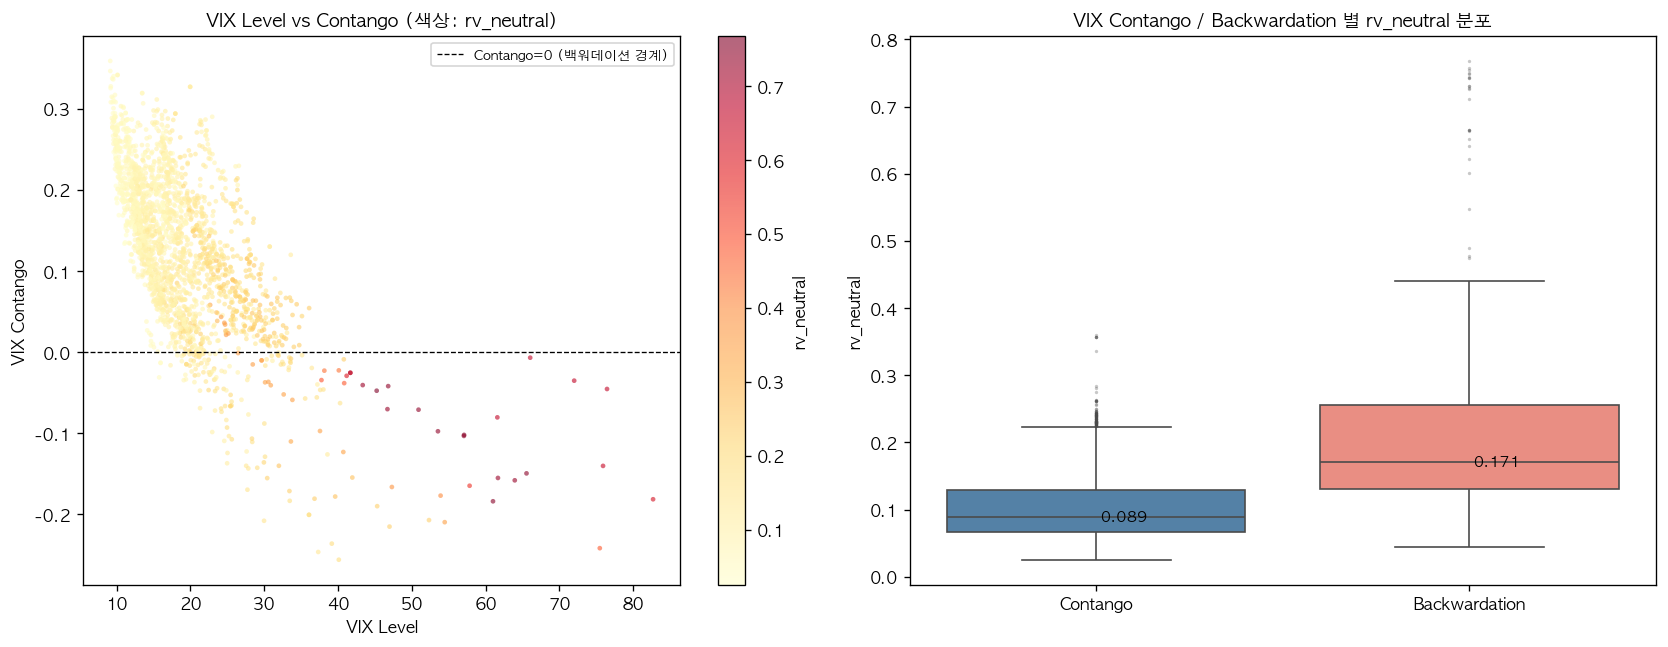

→ images/step2_03_vix_contango.png 저장 완료


In [24]:
# ── Viz 3: VIX level vs VIX contango scatter + boxplot ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Scatter
ax = axes[0]
valid = df_reg_v2[['VIX_level', 'VIX_contango', 'rv_neutral']].dropna()
sc = ax.scatter(valid['VIX_level'], valid['VIX_contango'],
                c=valid['rv_neutral'], cmap='YlOrRd', s=8, alpha=0.6, edgecolors='none')
ax.axhline(0, color='black', ls='--', lw=0.8, label='Contango=0 (백워데이션 경계)')
ax.set_xlabel('VIX Level')
ax.set_ylabel('VIX Contango')
ax.set_title('VIX Level vs Contango (색상: rv_neutral)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label='rv_neutral')

# Boxplot: Contango vs Backwardation → rv_neutral
ax = axes[1]
valid['regime'] = np.where(valid['VIX_contango'] >= 0, 'Contango', 'Backwardation')
order = ['Contango', 'Backwardation']
palette = {'Contango': 'steelblue', 'Backwardation': 'salmon'}
sns.boxplot(data=valid, x='regime', y='rv_neutral', order=order, palette=palette, ax=ax,
            flierprops=dict(marker='.', markersize=2, alpha=0.3))
ax.set_title('VIX Contango / Backwardation 별 rv_neutral 분포', fontsize=11, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('rv_neutral')

# 중앙값 표시
for i, regime in enumerate(order):
    med = valid[valid['regime'] == regime]['rv_neutral'].median()
    ax.text(i, med, f' {med:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
fig.savefig(IMG / 'step2_03_vix_contango.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ images/step2_03_vix_contango.png 저장 완료')

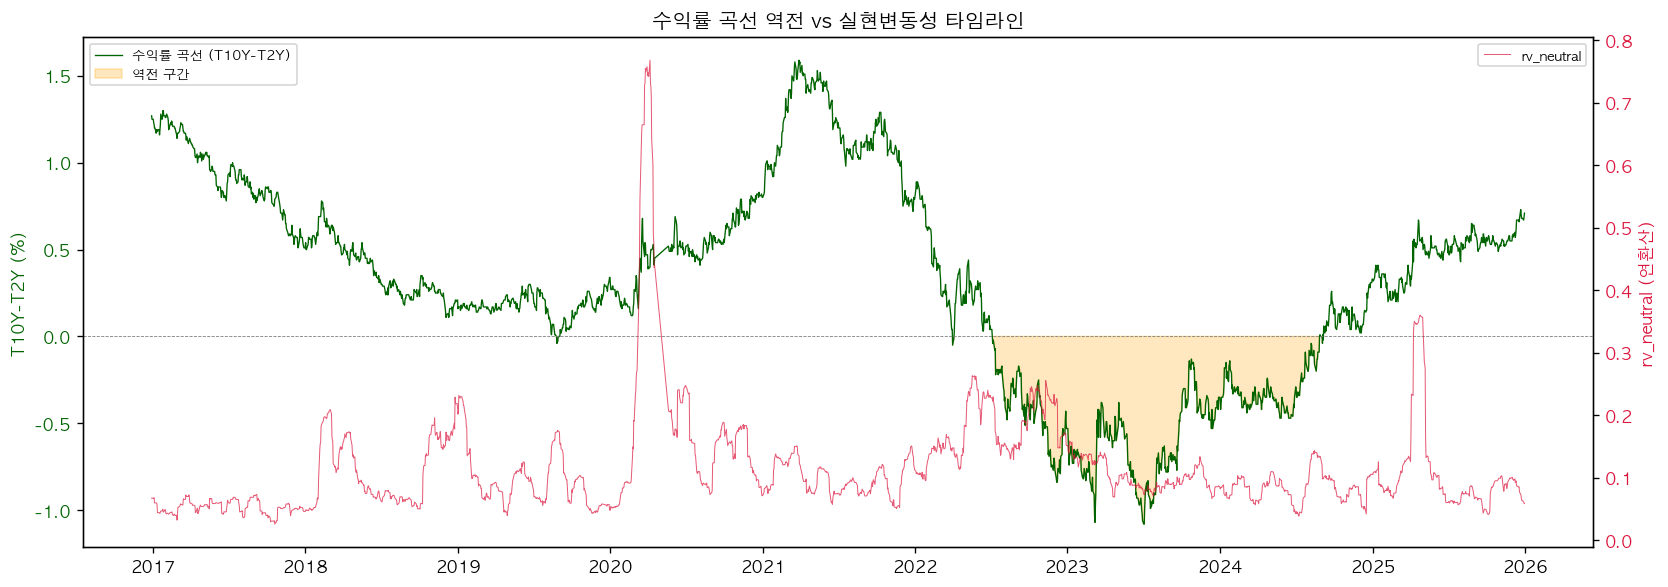

→ images/step2_04_yield_curve.png 저장 완료


In [25]:
# ── Viz 4: 수익률 곡선 역전 타임라인 ────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

yc = df_reg_v2['yield_curve'].dropna()
rv = df_reg_v2['rv_neutral'].dropna()

# Yield curve
ax1.plot(yc.index, yc.values, color='darkgreen', lw=0.8, label='수익률 곡선 (T10Y-T2Y)')
ax1.fill_between(yc.index, yc.values, 0,
                 where=yc.values < 0, color='orange', alpha=0.25, label='역전 구간')
ax1.axhline(0, color='gray', ls='--', lw=0.5)
ax1.set_ylabel('T10Y-T2Y (%)', color='darkgreen')
ax1.tick_params(axis='y', labelcolor='darkgreen')
ax1.legend(loc='upper left', fontsize=8)

# rv_neutral overlay
ax2 = ax1.twinx()
ax2.plot(rv.index, rv.values, color='crimson', lw=0.6, alpha=0.7, label='rv_neutral')
ax2.set_ylabel('rv_neutral (연환산)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.legend(loc='upper right', fontsize=8)

ax1.set_title('수익률 곡선 역전 vs 실현변동성 타임라인', fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(IMG / 'step2_04_yield_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ images/step2_04_yield_curve.png 저장 완료')

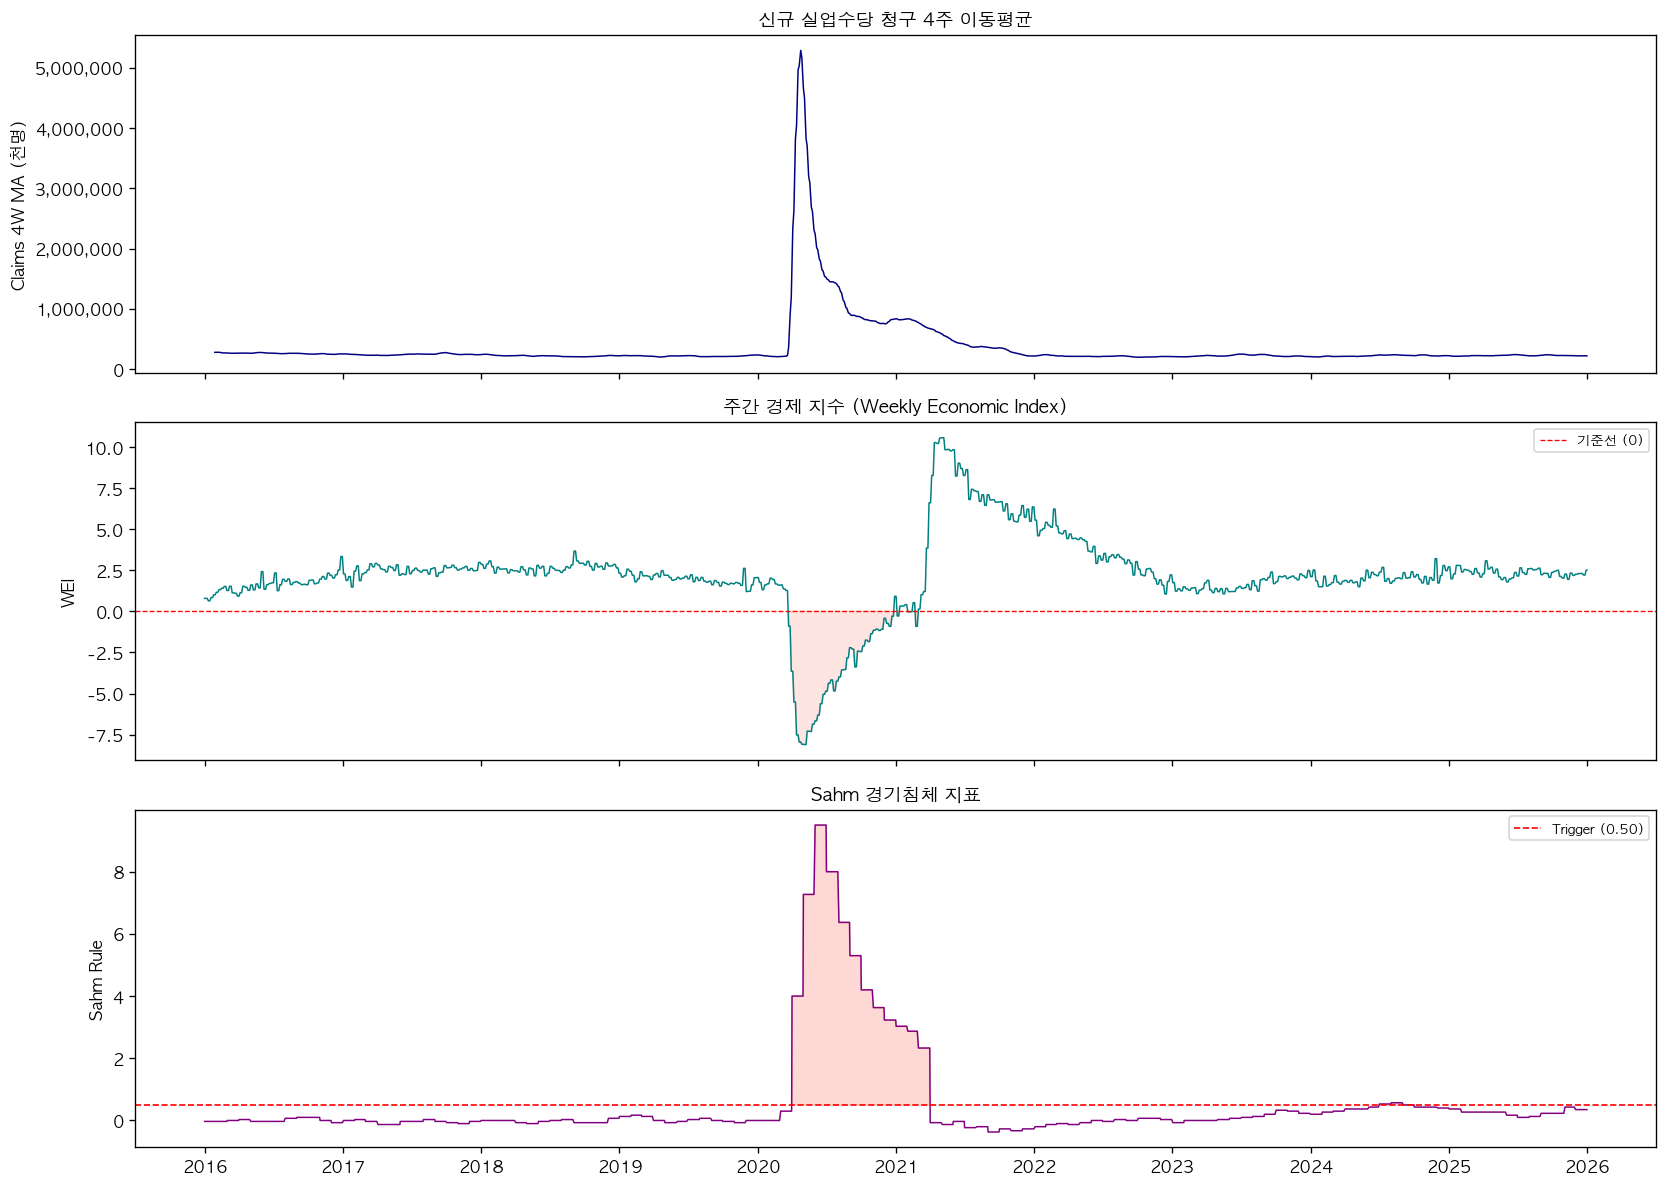

→ images/step2_05_macro_nowcast.png 저장 완료


In [26]:
# ── Viz 5: 주간 매크로 Nowcasting (3-panel) ─────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# (a) 실업수당 4주 이동평균
ax = axes[0]
cl = feat['claims_4wma'].dropna()
ax.plot(cl.index, cl.values, color='navy', lw=0.9)
ax.set_ylabel('Claims 4W MA (천명)')
ax.set_title('신규 실업수당 청구 4주 이동평균', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# (b) WEI
ax = axes[1]
wei = feat['WEI_level'].dropna()
ax.plot(wei.index, wei.values, color='teal', lw=0.9)
ax.axhline(0, color='red', ls='--', lw=0.8, label='기준선 (0)')
ax.fill_between(wei.index, wei.values, 0,
                where=wei.values < 0, color='salmon', alpha=0.2)
ax.set_ylabel('WEI')
ax.set_title('주간 경제 지수 (Weekly Economic Index)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)

# (c) Sahm Indicator
ax = axes[2]
sahm = feat['sahm_indicator'].dropna()
ax.plot(sahm.index, sahm.values, color='purple', lw=0.9)
ax.axhline(0.50, color='red', ls='--', lw=1.0, label='Trigger (0.50)')
ax.fill_between(sahm.index, sahm.values, 0.50,
                where=sahm.values >= 0.50, color='salmon', alpha=0.3)
ax.set_ylabel('Sahm Rule')
ax.set_title('Sahm 경기침체 지표', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(IMG / 'step2_05_macro_nowcast.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ images/step2_05_macro_nowcast.png 저장 완료')

## 2-5. Granger 인과 검정

Granger 인과 검정은 **"X의 과거값이 Y 예측에 통계적으로 유의미한 정보를 추가하는가?"**를 검증합니다.

- H₀: X는 Y를 Granger-cause하지 않는다
- H₁: X는 Y를 Granger-cause한다
- **대상**: df_reg_v2의 모든 수치형 변수 → `rv_neutral`
- **최대 시차**: 10일 (`maxlag=10`)
- 각 변수별로 1~10 lag의 F-test p-value 중 **최소 p-value**와 해당 lag 추출

In [27]:
# ── 2-5. Granger 인과 검정 ───────────────────────────────────
from statsmodels.tsa.stattools import grangercausalitytests

target = 'rv_neutral'
candidates = [c for c in df_reg_v2.select_dtypes(include=[np.number]).columns if c != target]

results = []
for col in candidates:
    sub = df_reg_v2[[target, col]].dropna()
    if len(sub) < 50:
        continue
    try:
        gc = grangercausalitytests(sub, maxlag=10, verbose=False)
        pvals = {lag: gc[lag][0]['ssr_ftest'][1] for lag in range(1, 11)}
        best_lag = min(pvals, key=pvals.get)
        min_p = pvals[best_lag]
        results.append({'variable': col, 'best_lag': best_lag, 'p_value': min_p})
    except Exception:
        pass

granger_df = pd.DataFrame(results).sort_values('p_value').reset_index(drop=True)
granger_df['significant'] = granger_df['p_value'] < 0.05
granger_df.to_csv(DATA / 'granger_results.csv', index=False)

print(f'Granger 검정 완료: {len(granger_df)}개 변수')
print(f'유의미 (p < 0.05): {granger_df["significant"].sum()}개')
print(f'\n→ data/granger_results.csv 저장 완료')
print('\n── Top 20 ──')
print(granger_df.head(20).to_string(index=False))

Granger 검정 완료: 43개 변수
유의미 (p < 0.05): 34개

→ data/granger_results.csv 저장 완료

── Top 20 ──
       variable  best_lag      p_value  significant
  HY_spread_chg         1 7.209847e-65         True
VIX_slope_9d_3m         1 1.862877e-60         True
      VIX_level         1 1.357175e-47         True
VIX_slope_3m_6m         1 5.989102e-43         True
    claims_4wma         2 4.911881e-34         True
      HY_spread         6 1.567725e-32         True
   VIX_contango         1 1.611115e-24         True
     CL=F_vol21         9 1.707201e-24         True
         UNRATE        10 1.976656e-23         True
  BTC-USD_vol21         7 1.654719e-13         True
         ^VIX6M        10 2.862967e-13         True
           ^VIX        10 8.375512e-13         True
  ETH-USD_vol21         7 3.682975e-12         True
         ^VIX3M        10 1.209175e-11         True
         ^VIX9D        10 2.169847e-11         True
 sahm_indicator        10 2.709220e-11         True
   ^VIX9D_vol21         1 

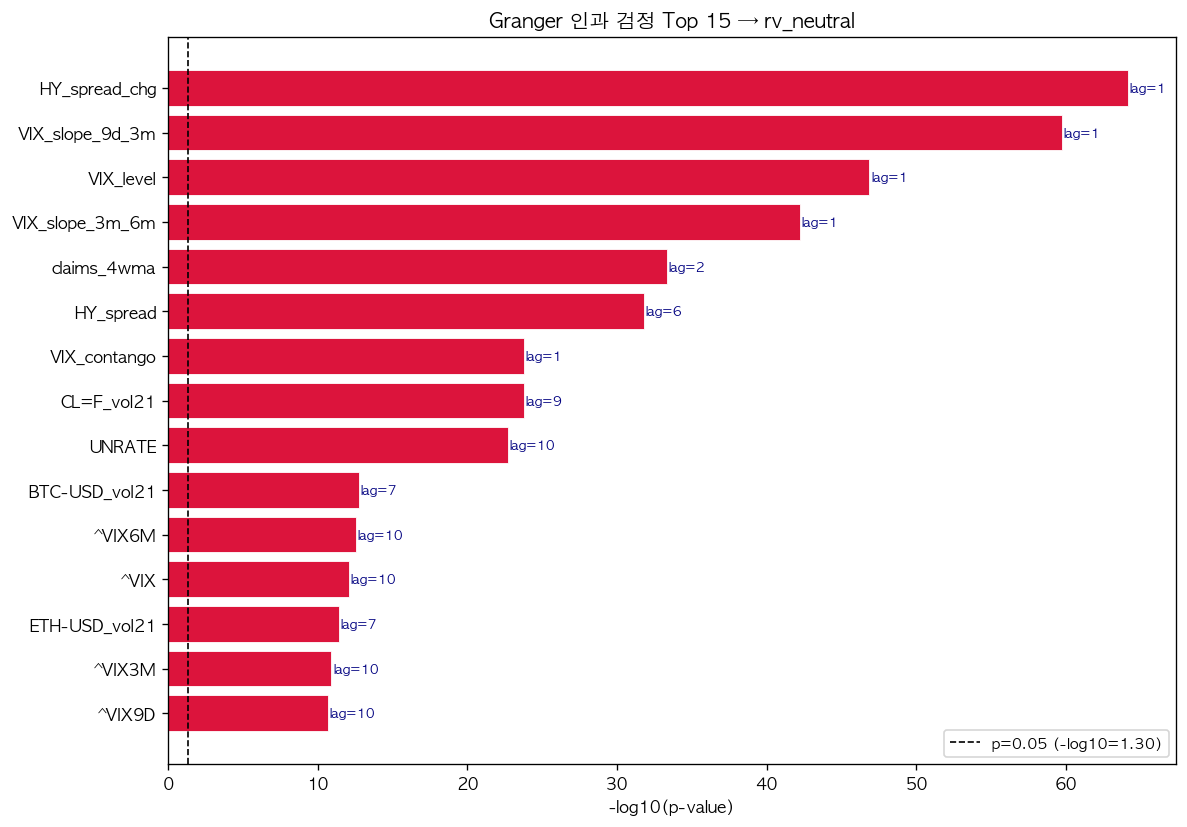

→ images/step2_06_granger.png 저장 완료


In [28]:
# ── Viz 6: Granger Top 15 수평 막대 ─────────────────────────────
top15 = granger_df.head(15).copy()
top15['-log10(p)'] = -np.log10(top15['p_value'].clip(lower=1e-300))
top15 = top15.sort_values('-log10(p)', ascending=True)  # 높은 것이 위

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['crimson' if p < 0.05 else 'gray' for p in top15['p_value']]
ax.barh(top15['variable'], top15['-log10(p)'], color=colors, edgecolor='white', linewidth=0.5)

# 유의 기준선
sig_line = -np.log10(0.05)
ax.axvline(sig_line, color='black', ls='--', lw=1, label=f'p=0.05 (-log10={sig_line:.2f})')

ax.set_xlabel('-log10(p-value)', fontsize=10)
ax.set_title('Granger 인과 검정 Top 15 → rv_neutral', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# lag 표시
for i, (_, row) in enumerate(top15.iterrows()):
    ax.text(row['-log10(p)'] + 0.1, i, f"lag={int(row['best_lag'])}",
            va='center', fontsize=8, color='navy')

plt.tight_layout()
fig.savefig(IMG / 'step2_06_granger.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ images/step2_06_granger.png 저장 완료')

In [29]:
# ── 최종 요약 ────────────────────────────────────────────────
import glob

imgs = sorted(glob.glob(str(IMG / 'step2_*.png')))

print('=' * 60)
print('  Step 2 전처리 + 피처 엔지니어링 + EDA 완료')
print('=' * 60)
print(f'  df_reg_v2 shape    : {df_reg_v2.shape[0]:,} rows × {df_reg_v2.shape[1]} cols')
print(f'  파생 변수          : {len(FEATURE_NAMES)}개')
print(f'  Granger 유의 변수  : {granger_df["significant"].sum()}개 / {len(granger_df)}개 (p < 0.05)')
print(f'  저장 이미지        : {len(imgs)}개')
for img in imgs:
    print(f'    - {os.path.basename(img)}')
print('=' * 60)

  Step 2 전처리 + 피처 엔지니어링 + EDA 완료
  df_reg_v2 shape    : 2,328 rows × 44 cols
  파생 변수          : 15개
  Granger 유의 변수  : 34개 / 43개 (p < 0.05)
  저장 이미지        : 9개
    - step2_01_dashboard.png
    - step2_02_correlation.png
    - step2_03_vix_contango.png
    - step2_04_yield_curve.png
    - step2_05_macro_nowcast.png
    - step2_06_granger.png
    - step2_eda2_distribution.png
    - step2_eda3_adf.png
    - step2_eda4_vif.png


## EDA

### 1. 기초통계

In [32]:
# ── 원본 데이터 기초 통계 & 결측치 ───────────────────────────────
port = pd.read_csv(DATA / 'portfolio_prices.csv', index_col=0, parse_dates=True)
ext  = pd.read_csv(DATA / 'external_prices.csv',  index_col=0, parse_dates=True)
fred = pd.read_csv(DATA / 'fred_data.csv',         index_col=0, parse_dates=True)

for name, df in [('포트폴리오 (30개)', port), ('외부 지표 (12개)', ext), ('FRED (8개)', fred)]:
    print(f'\n{"=" * 55}')
    print(f'  {name}')
    print(f'  shape : {df.shape}  |  기간 : {df.index[0].date()} ~ {df.index[-1].date()}')
    print(f'  결측치: {df.isnull().sum().sum()}개')
    stats = df.describe().T[['mean', 'std', 'min', 'max']]
    stats['skewness'] = df.skew()
    stats['kurtosis'] = df.kurt()
    display(stats.round(2))


  포트폴리오 (30개)
  shape : (2609, 30)  |  기간 : 2016-01-01 ~ 2025-12-31
  결측치: 0개


,mean,std,min,max,skewness,kurtosis
SPY,353.70,136.73,154.56,688.50,0.60,-0.59
QQQ,281.18,141.08,89.47,634.15,0.58,-0.65
IWM,164.81,39.63,83.12,256.48,0.11,-0.95
EFA,60.75,12.71,38.09,96.57,0.64,-0.08
EEM,38.26,6.27,22.63,55.22,0.25,0.07
TLT,101.99,16.35,74.54,144.32,0.85,-0.32
AGG,90.82,5.70,81.31,101.33,0.31,-1.28
SHY,73.69,3.23,69.37,82.13,0.62,-0.33
TIP,97.43,8.17,82.58,111.77,-0.07,-1.38
GLD,171.24,60.32,102.89,416.74,1.69,2.90



  외부 지표 (12개)
  shape : (2609, 12)  |  기간 : 2016-01-01 ~ 2025-12-31
  결측치: 0개


,mean,std,min,max,skewness,kurtosis
CL=F,63.61,17.51,-37.63,123.70,0.22,0.81
GC=F,1831.55,667.31,1073.90,4529.10,1.67,2.81
SI=F,22.53,8.08,11.73,77.37,2.24,7.96
BTC-USD,30289.91,32084.90,364.33,124752.53,1.20,0.43
ETH-USD,1431.65,1283.93,84.31,4831.35,0.70,-0.78
^VIX,18.46,7.29,9.14,82.69,2.55,12.47
DX-Y.NYB,98.52,5.02,88.59,114.11,0.36,-0.44
^VIX9D,17.63,8.89,7.10,106.66,3.37,20.59
^VIX3M,20.45,6.44,11.85,72.98,1.96,7.89
^VIX6M,21.83,5.69,13.75,61.11,1.30,2.88



  FRED (8개)
  shape : (2609, 8)  |  기간 : 2016-01-01 ~ 2025-12-31
  결측치: 0개


,mean,std,min,max,skewness,kurtosis
BAMLH0A0HYM2,4.11,1.17,2.59,10.87,1.84,4.19
T10Y2Y,0.38,0.58,-1.08,1.59,-0.29,-0.56
ICSA,364690.30,549447.36,190000.00,6137000.00,7.01,58.63
WEI,2.17,2.47,-8.11,10.57,-0.58,5.16
SAHMREALTIME,0.56,1.65,-0.37,9.50,3.56,12.78
DGS10,2.70,1.17,0.52,4.98,0.07,-1.15
CPIAUCSL,275.51,28.89,237.34,326.03,0.37,-1.43
UNRATE,4.58,1.72,3.40,14.80,3.70,15.75


[외부지표]  
1. CL=F 음수 : 2020년 WTI 원유 가격 마이너스 사건
- 발생일: 2020년 4월 20일
- 가격: 배럴당 –37.63달러(종가 기준)
- 원유 종류: WTI(서부텍사스산중질유)
- 거래소: 뉴욕상업거래소
- 주요 원인: 수요 급감, 저장시설 포화, 선물 만기 압박

[FRED]  
1. T10Y2Y (장단기 금리차) : 음수이면 경기 침체 신호  
2. WEI (경제 활동 종합 지표) : 음수이면 경기 둔화  
3. SAHMREALTIME (실업률 기반 경기침체 지표) : 0 이상이면 침체 신호

왜도 : ±1 이상 → 치우침 있음  
첨도 : 3보다 큼 → fat tail  / 음수 → 일정한 범위 내에서 안정적으로 분포

1. 높은 양의 왜도: ICSA(신규 실업수당 청구 건수, 7.01), SAHMREALTIME(샴 법칙 침체 지표, 3.56), UNRATE(실업률, 3.70)  
평소에는 낮게 유지되다가 위기 시에 수치가 비정상적으로 폭등하는 특성을 잘 보여줌
2. 안전자산/원자재: GLD(금 ETF, 1.69), GC=F(금 선물, 1.67), SI=F(은 선물, 2.24)는 양의 왜도를 가짐  
가격이 위로 크게 튀는 경향이 있음을 뜻함

3. 극단적 위험 (초고첨도): ICSA (58.63), ^VIX9D (20.59), UNRATE (15.75), ^VIX (12.47)  
변동성 지수나 고용 지표는 평온하다가도 순식간에 수치가 수 배로 뛰는 '**쇼크**'에 취약함을 보여줌
4. 가상화폐: BTC-USD(0.43)와 ETH-USD(-0.78)는 의외로 첨도가 낮게 측정됨  
분석 기간 내 수익률의 변동이 매우 컸음에도 불구하고, 특정 구간에 극단적으로 쏠리기보다는 전반적으로 넓은 변동폭을 상시 유지했기 때문일 수 있음

결론적으로, VIX와 실업 관련 지표들은 왜도와 첨도가 모두 매우 높아 "평소에는 안정적이다가 한 번 터지면 걷잡을 수 없는" 전형적인 위험 지표의 특성을 보여주고 있으며, 금과 은은 인플레이션이나 위기 상황에서 "상방 시너지가 강한" 자산임을 보여줌

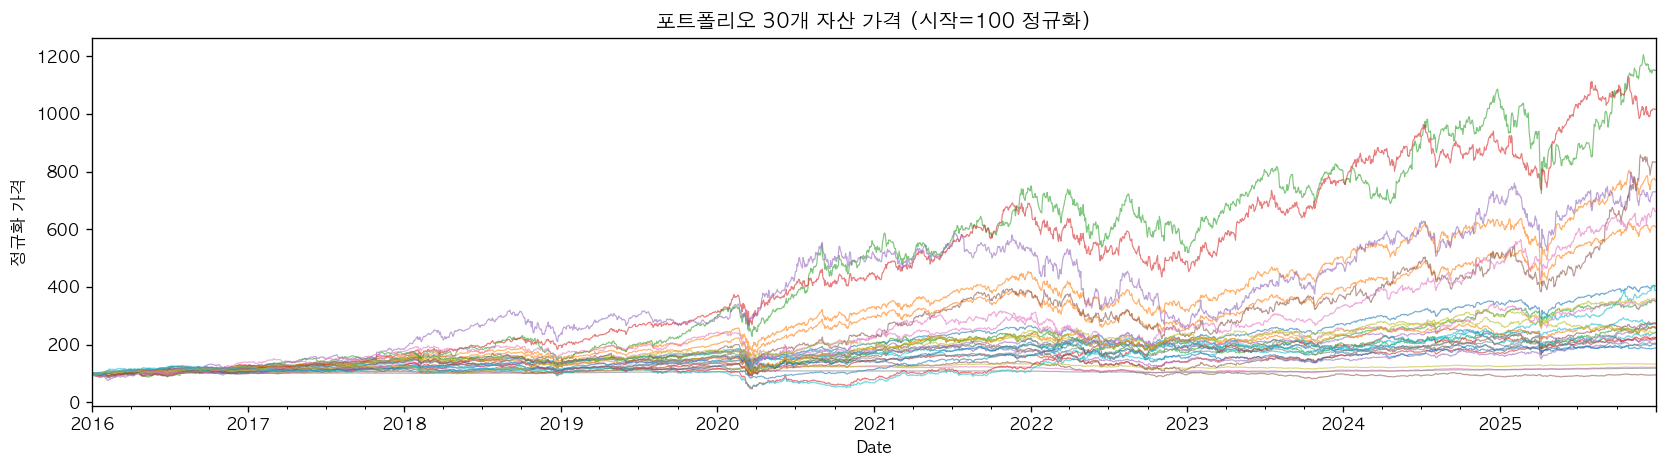

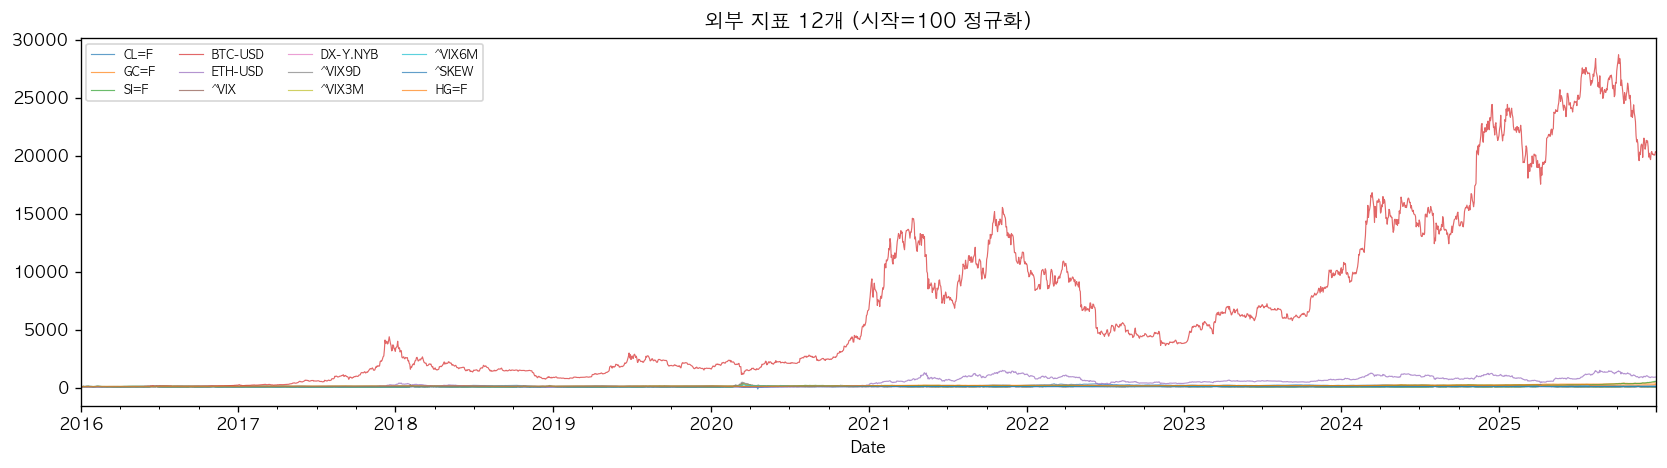

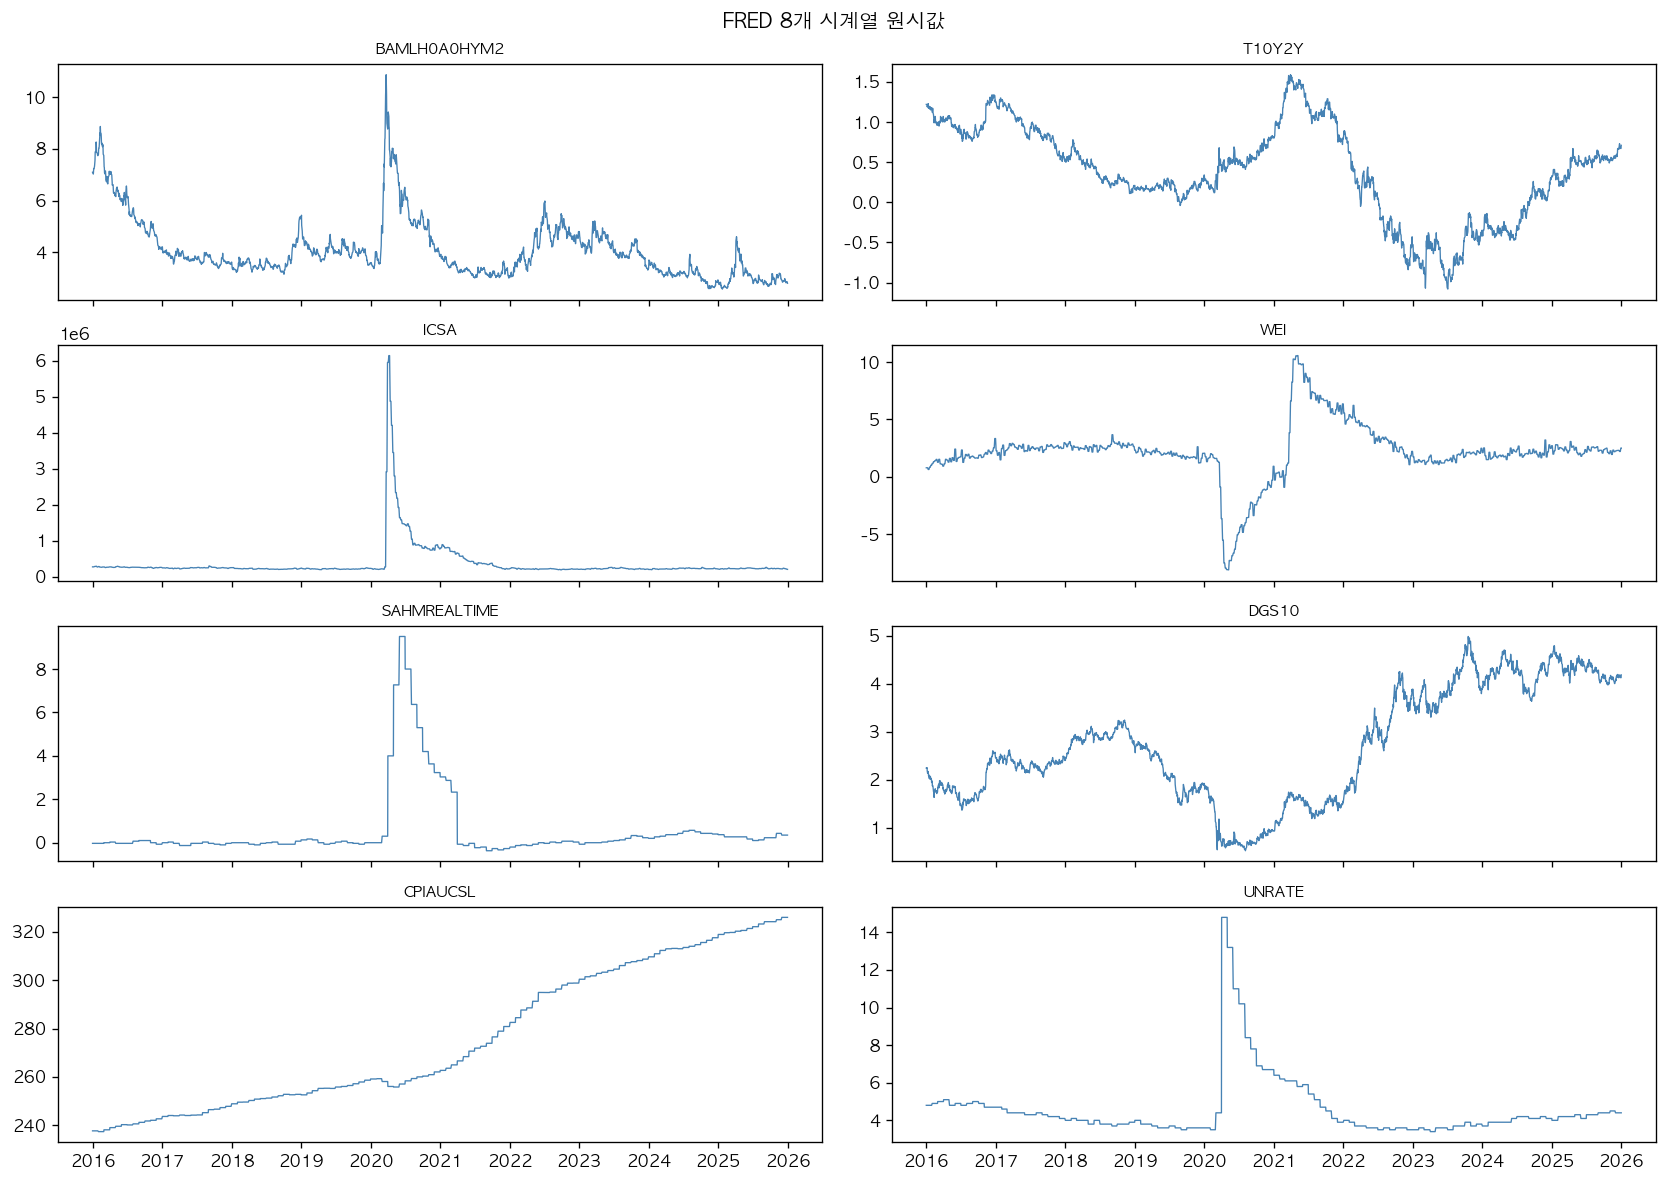

In [31]:
# ── 원본 시계열 시각화 ────────────────────────────────────────────

# (1) 포트폴리오 30개 — 시작=100 정규화
fig, ax = plt.subplots(figsize=(14, 4))
(port / port.iloc[0] * 100).plot(ax=ax, lw=0.7, legend=False, alpha=0.6)
ax.set_title('포트폴리오 30개 자산 가격 (시작=100 정규화)', fontsize=12, fontweight='bold')
ax.set_ylabel('정규화 가격')
plt.tight_layout()
plt.show()

# (2) 외부 지표 12개 — 시작=100 정규화
fig, ax = plt.subplots(figsize=(14, 4))
(ext / ext.iloc[0] * 100).plot(ax=ax, lw=0.7, alpha=0.7)
ax.set_title('외부 지표 12개 (시작=100 정규화)', fontsize=12, fontweight='bold')
ax.legend(fontsize=7, ncol=4, loc='upper left')
plt.tight_layout()
plt.show()

# (3) FRED 8개 — 각각 스케일이 달라서 개별 subplot
fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex=True)
for ax, col in zip(axes.flatten(), fred.columns):
    ax.plot(fred.index, fred[col], lw=0.8, color='steelblue')
    ax.set_title(col, fontsize=9, fontweight='bold')
plt.suptitle('FRED 8개 시계열 원시값', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


### 2. 정상성 확인
시계열 자료는 정규성이 아닌 정상성을 만족해야 함!
#### 정상성이란?
"시간이 지나도 통계적 성질이 유지되는 것" : 평균 일정 + 분산 일정 + 추세 없음 -> ARIMA 같은 모델이 이걸 가정함
* 주가: 가격(Price) 데이터이므로 로그 수익률로 변환하여 '비율'로 만듦. (로그 수익률도 차분 개념)
* VIX: 변동성(Volatility)이라는 '지수/비율' 데이터이므로 단순 차분을 통해 '변화량'만 추출함.

In [37]:
from statsmodels.tsa.stattools import adfuller

def adf_test(df, name):
    results = []
    for col in df.columns:
        series = df[col].dropna()
        adf_stat, p_val, *_ = adfuller(series, autolag='AIC')
        results.append({
            'variable':   col,
            'ADF_stat':   round(adf_stat, 4),
            'p_value':    round(p_val, 4),
            'stationary': '정상' if p_val < 0.05 else '비정상'
        })
    result_df = pd.DataFrame(results).sort_values('p_value', ascending=False)
    
    n_non = (result_df['stationary'] == '비정상').sum()
    print(f'\n{"=" * 50}')
    print(f'  {name}  |  비정상: {n_non}/{len(result_df)}개')
    print(f'{"=" * 50}')
    return result_df

adf_port = adf_test(port, '포트폴리오 (30개)')
display(adf_port)
adf_ext  = adf_test(ext,  '외부 지표 (12개)')
display(adf_ext)
adf_fred = adf_test(fred, 'FRED (8개)')
display(adf_fred)


  포트폴리오 (30개)  |  비정상: 30/30개


,variable,ADF_stat,p_value,stationary
9,GLD,4.3057,1.0000,비정상
25,GOOGL,2.2776,0.9989,비정상
26,JPM,1.7648,0.9983,비정상
7,SHY,1.3308,0.9968,비정상
11,XLK,1.0423,0.9947,비정상
0,SPY,0.9329,0.9935,비정상
1,QQQ,0.8874,0.9929,비정상
15,VOX,0.6841,0.9895,비정상
22,AAPL,0.3990,0.9815,비정상
18,XLI,0.3440,0.9793,비정상



  외부 지표 (12개)  |  비정상: 7/12개


,variable,ADF_stat,p_value,stationary
1,GC=F,4.8216,1.0000,비정상
2,SI=F,4.6715,1.0000,비정상
11,HG=F,-0.7627,0.8298,비정상
3,BTC-USD,-0.8674,0.7985,비정상
4,ETH-USD,-2.0051,0.2843,비정상
6,DX-Y.NYB,-2.1149,0.2385,비정상
0,CL=F,-2.6290,0.0871,비정상
9,^VIX6M,-3.0352,0.0317,정상
10,^SKEW,-3.5655,0.0065,정상
8,^VIX3M,-3.6249,0.0053,정상



  FRED (8개)  |  비정상: 3/8개


,variable,ADF_stat,p_value,stationary
6,CPIAUCSL,0.8406,0.9923,비정상
5,DGS10,-0.7530,0.8326,비정상
1,T10Y2Y,-1.6394,0.4626,비정상
7,UNRATE,-3.2414,0.0177,정상
3,WEI,-3.3510,0.0127,정상
4,SAHMREALTIME,-3.8216,0.0027,정상
0,BAMLH0A0HYM2,-3.8757,0.0022,정상
2,ICSA,-4.8389,0.0000,정상


#### 정상성 검정 결과에 따른 변환 기준

> **목적**: 고객 맞춤 자산배분 펀드 추천을 위한 리스크 관리 모델
> 모델에 투입하는 모든 변수는 **정상(stationary)** 이어야 함

---

##### 비정상 (ADF p ≥ 0.05) → 변환 필요

| 변수 유형 | 해당 변수 | 변환 방법 | 이유 |
|---|---|---|---|
| 자산 가격 | SPY, QQQ 등 30개, CL=F, GC=F, BTC 등 | 로그 수익률 `ln(Pt/Pt-1)` | 포트폴리오 최적화 입력값. 수익률이 투자 관점에서 의미 있음 |
| 금리·실업률·물가 | DGS10, UNRATE, CPIAUCSL | 단순 차분 `diff()` | 수준값보다 변화 방향이 리스크 신호 |

---

##### 정상 (ADF p < 0.05) → 수준값 그대로 사용

| 변수 유형 | 해당 변수 | 이유 |
|---|---|---|
| 스프레드 | T10Y2Y, BAMLH0A0HYM2 | 스프레드 수준 자체가 신용·경기 리스크 지표 |
| 변동성 지수 | ^VIX, ^VIX9D, ^VIX3M, ^VIX6M | VIX 수준값이 현재 시장 리스크를 직접 표현 |
| 경기 지표 | WEI, SAHMREALTIME | 리스크 신호용으로 설계된 지수 |

---

##### 핵심 판단 기준

```
ADF p < 0.05  →  정상  →  그대로 사용
ADF p ≥ 0.05  →  비정상  →  로그수익률 or 차분 후 재검정
```

- VIX는 평균회귀(mean-reverting) 특성으로 수준값이 정상일 가능성 높음 → **수준값 유지**
- 스프레드(T10Y2Y 등)는 수준값이 리스크 해석에 직접 유용 → **수준값 유지**
- 주가·원자재는 우상향 트렌드로 비정상 → **로그수익률 변환**


In [39]:
# ── 비정상 변수 변환 후 재검정 ─────────────────────────────────

VIX_COLS = [c for c in ext.columns if 'VIX' in c.upper()]

# 1. 비정상 변수 추출
nonstat_port = adf_port[adf_port['stationary'] == '비정상']['variable'].tolist()
nonstat_ext  = adf_ext[adf_ext['stationary']   == '비정상']['variable'].tolist()
nonstat_fred = adf_fred[adf_fred['stationary']  == '비정상']['variable'].tolist()

print(f'비정상 변수 수 — 포트폴리오: {len(nonstat_port)}, 외부지표: {len(nonstat_ext)}, FRED: {len(nonstat_fred)}')

# 2. 변환
# 포트폴리오 → 로그수익률
port_trans = np.log(port[nonstat_port] / port[nonstat_port].shift(1)).dropna()

# 외부지표 → VIX계열 차분 / 나머지 로그수익률
nonstat_vix    = [c for c in nonstat_ext if c in VIX_COLS]
nonstat_ext_nv = [c for c in nonstat_ext if c not in VIX_COLS]

ext_trans = pd.concat([
    np.log(ext[nonstat_ext_nv] / ext[nonstat_ext_nv].shift(1)) if nonstat_ext_nv else pd.DataFrame(),
    ext[nonstat_vix].diff() if nonstat_vix else pd.DataFrame()
], axis=1).dropna()

# FRED → 단순 차분
fred_trans = fred[nonstat_fred].diff().dropna() if nonstat_fred else pd.DataFrame()

# 3. 재검정
print('\n변환 후 재검정')
if not port_trans.empty:
    adf_port2 = adf_test(port_trans, '포트폴리오 → 로그수익률')
    adf_port2.insert(1, '변환방법', '로그수익률')
    display(adf_port2)

if not ext_trans.empty:
    adf_ext2 = adf_test(ext_trans, '외부지표 → 로그수익률')
    trans_map = {c: '로그수익률' for c in nonstat_ext_nv}
    trans_map.update({c: '차분' for c in nonstat_vix})
    adf_ext2.insert(1, '변환방법', adf_ext2['variable'].map(trans_map))
    display(adf_ext2)

if not fred_trans.empty:
    adf_fred2 = adf_test(fred_trans, 'FRED → 차분')
    adf_fred2.insert(1, '변환방법', '차분')
    display(adf_fred2)

비정상 변수 수 — 포트폴리오: 30, 외부지표: 7, FRED: 3

변환 후 재검정

  포트폴리오 → 로그수익률  |  비정상: 0/30개


,variable,변환방법,ADF_stat,p_value,stationary
0,GLD,로그수익률,-51.1802,0.0,정상
1,GOOGL,로그수익률,-13.5352,0.0,정상
28,EEM,로그수익률,-11.4550,0.0,정상
27,TLT,로그수익률,-9.9527,0.0,정상
26,PG,로그수익률,-16.9093,0.0,정상
25,IWM,로그수익률,-13.2010,0.0,정상
24,XLB,로그수익률,-14.3382,0.0,정상
23,AGG,로그수익률,-10.4959,0.0,정상
22,DBC,로그수익률,-49.1572,0.0,정상
21,TIP,로그수익률,-11.0963,0.0,정상



  외부지표 → 로그수익률  |  비정상: 0/7개


,variable,변환방법,ADF_stat,p_value,stationary
0,GC=F,로그수익률,-13.4033,0.0,정상
1,SI=F,로그수익률,-34.3092,0.0,정상
2,HG=F,로그수익률,-52.9032,0.0,정상
3,BTC-USD,로그수익률,-51.7662,0.0,정상
4,ETH-USD,로그수익률,-18.5693,0.0,정상
5,DX-Y.NYB,로그수익률,-50.1899,0.0,정상
6,CL=F,로그수익률,-9.6633,0.0,정상



  FRED → 차분  |  비정상: 0/3개


,variable,변환방법,ADF_stat,p_value,stationary
0,CPIAUCSL,차분,-6.0230,0.0,정상
1,DGS10,차분,-37.8077,0.0,정상
2,T10Y2Y,차분,-9.8272,0.0,정상


### 3. 상관관계 분석

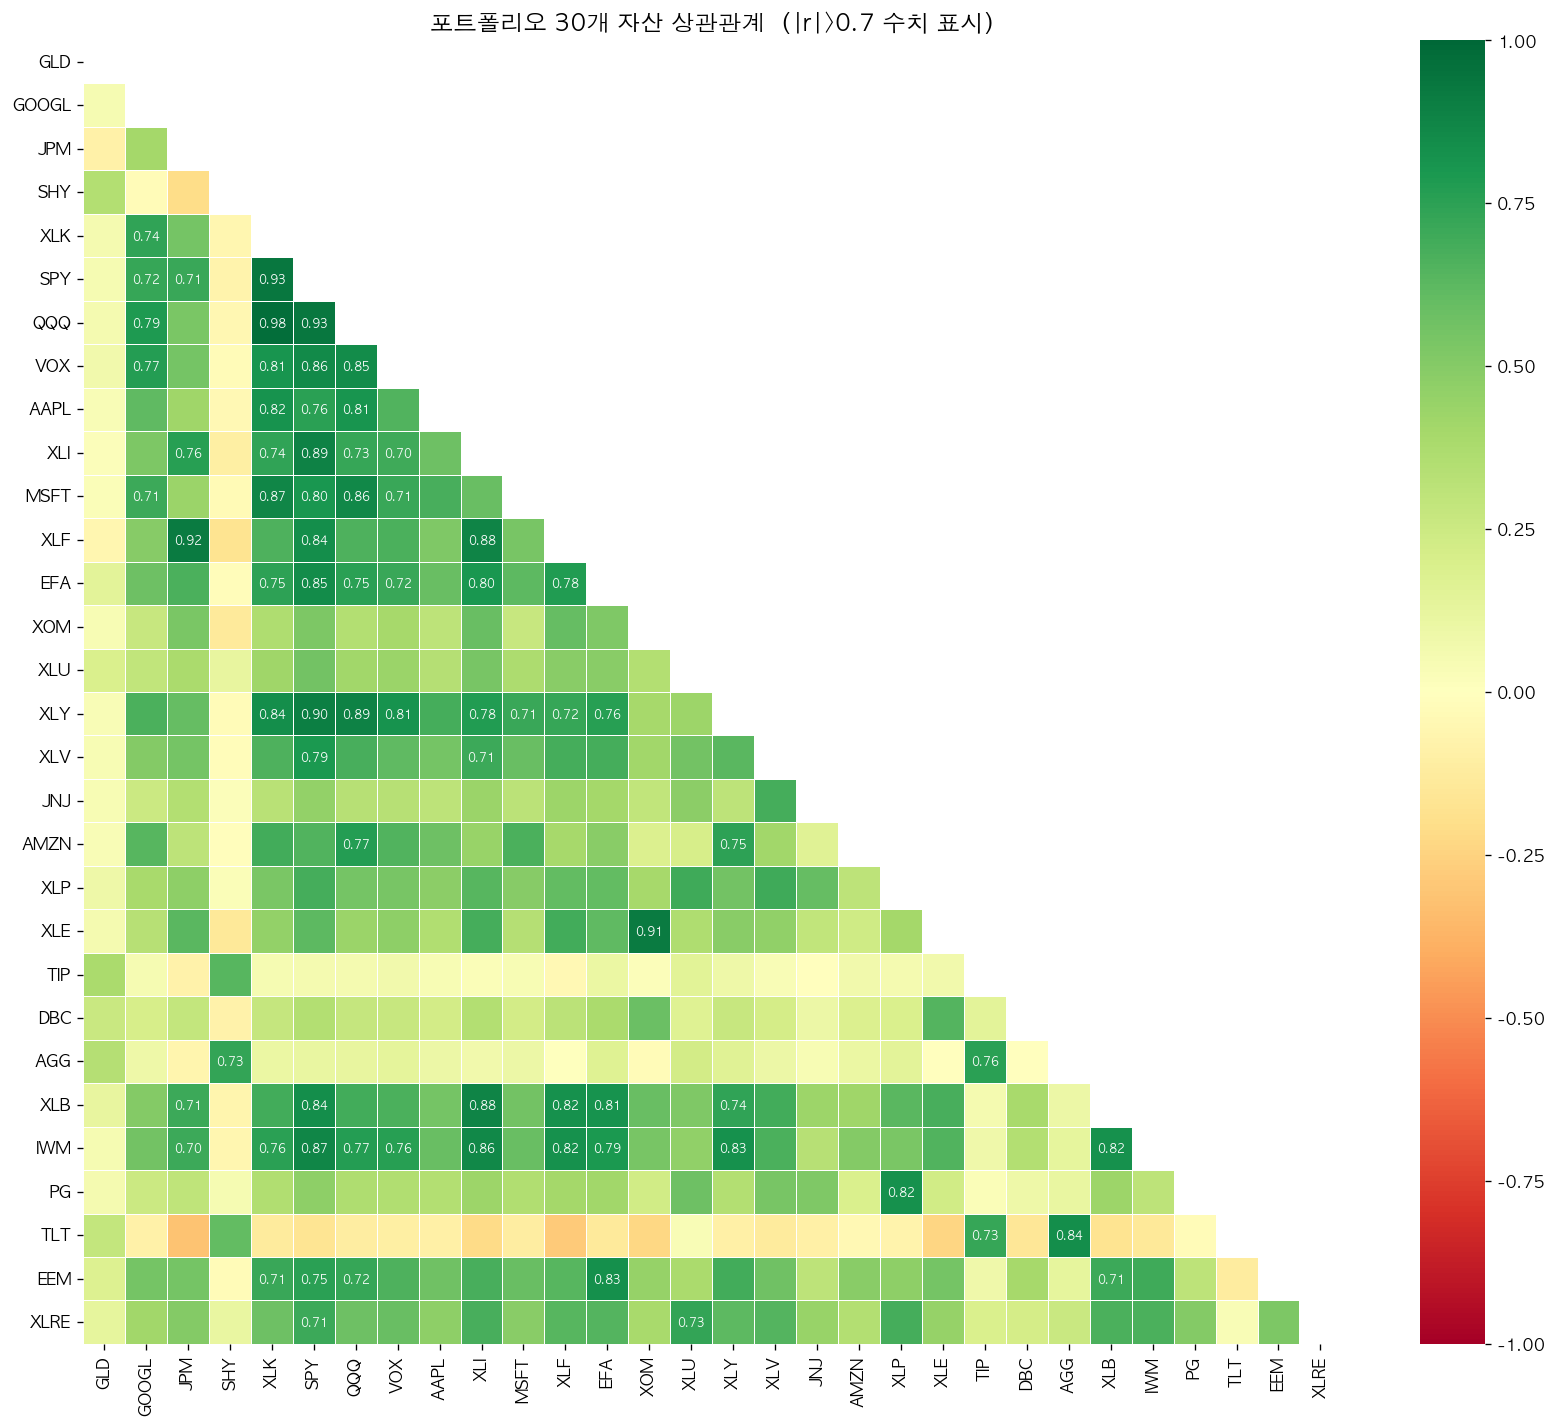

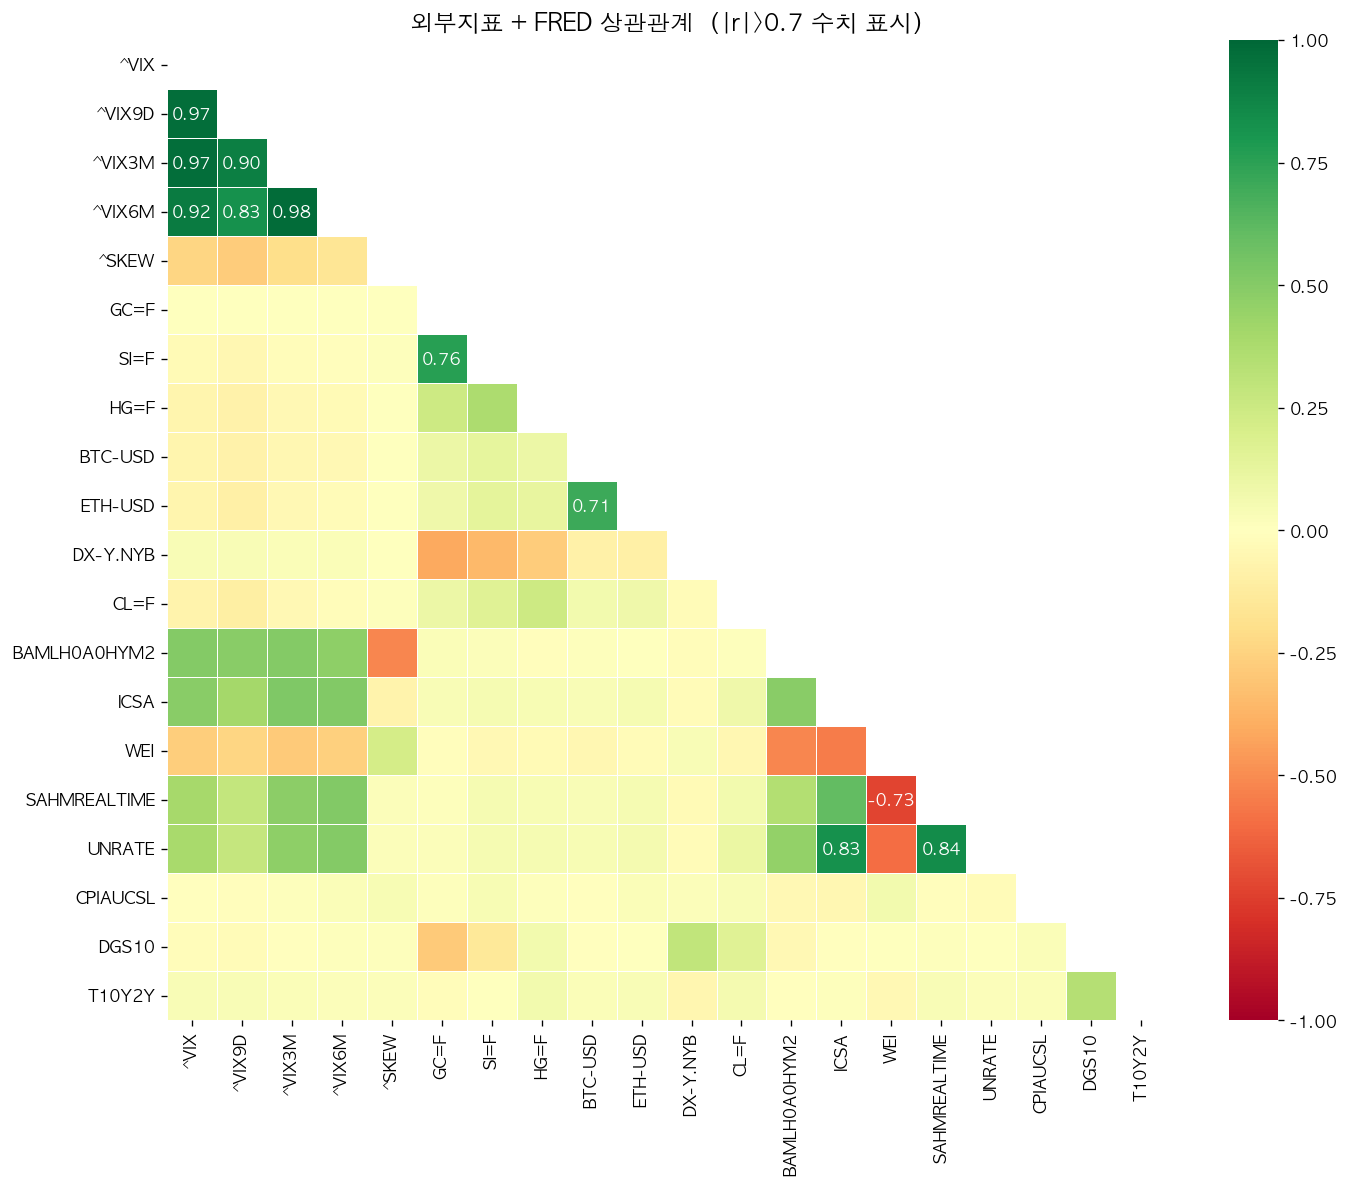


  포트폴리오 (30개)  |  고상관 쌍: 74개


,변수1,변수2,상관계수
12,XLK,QQQ,0.9750
21,SPY,QQQ,0.9333
11,XLK,SPY,0.9300
7,JPM,XLF,0.9162
63,XOM,XLE,0.9145
28,SPY,XLY,0.8992
24,SPY,XLI,0.8881
39,QQQ,XLY,0.8863
52,XLI,XLB,0.8807
48,XLI,XLF,0.8753



  외부지표 + FRED  |  고상관 쌍: 11개


,변수1,변수2,상관계수
5,^VIX3M,^VIX6M,0.9828
1,^VIX,^VIX3M,0.9716
0,^VIX,^VIX9D,0.9712
2,^VIX,^VIX6M,0.9196
3,^VIX9D,^VIX3M,0.9050
10,SAHMREALTIME,UNRATE,0.8444
4,^VIX9D,^VIX6M,0.8281
8,ICSA,UNRATE,0.8251
6,GC=F,SI=F,0.7612
9,WEI,SAHMREALTIME,-0.7307


In [46]:
# ── 상관관계 분석 ─────────────────────────────────────────────

# 1. 정상 변수 통합 (원본 정상 + 변환된 비정상)
stat_port = [c for c in port.columns if c not in nonstat_port]
stat_ext  = [c for c in ext.columns  if c not in nonstat_ext]
stat_fred = [c for c in fred.columns if c not in nonstat_fred]

port_final = pd.concat([port[stat_port], port_trans], axis=1).dropna()
ext_final  = pd.concat([ext[stat_ext],   ext_trans],  axis=1).dropna()
fred_final = pd.concat([fred[stat_fred],  fred_trans], axis=1).dropna()

# 2. 포트폴리오 자산 간 상관관계 (30×30)
corr_port = port_final.corr()
annot_port = corr_port.map(lambda x: f"{x:.2f}" if abs(x) > 0.7 else "")
mask = np.triu(np.ones_like(corr_port, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_port, mask=mask, annot=annot_port, fmt="", cmap="RdYlGn",
            vmin=-1, vmax=1, center=0, ax=ax, linewidths=0.3, annot_kws={"size": 7})
ax.set_title("포트폴리오 30개 자산 상관관계  (|r|>0.7 수치 표시)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 3. 외부지표 + FRED 상관관계
ext_fred = pd.concat([ext_final, fred_final], axis=1).dropna()
corr_ef  = ext_fred.corr()
annot_ef = corr_ef.map(lambda x: f"{x:.2f}" if abs(x) > 0.7 else "")
mask2 = np.triu(np.ones_like(corr_ef, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_ef, mask=mask2, annot=annot_ef, fmt="", cmap="RdYlGn",
            vmin=-1, vmax=1, center=0, ax=ax, linewidths=0.5)
ax.set_title("외부지표 + FRED 상관관계  (|r|>0.7 수치 표시)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# 4. 고상관 변수 쌍 (|r| > 0.7)
def high_corr_pairs(corr_matrix, label):
    pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            r = corr_matrix.iloc[i, j]
            if abs(r) > 0.7:
                pairs.append({"변수1": cols[i], "변수2": cols[j], "상관계수": round(r, 4)})
    print(f"\n{'='*50}")
    print(f"  {label}  |  고상관 쌍: {len(pairs)}개")
    print(f"{'='*50}")
    if pairs:
        display(pd.DataFrame(pairs).sort_values("상관계수", key=lambda x: x.abs(), ascending=False))
    else:
        print("없음")

high_corr_pairs(corr_port, "포트폴리오 (30개)")
high_corr_pairs(corr_ef,   "외부지표 + FRED")


### 4. VIF (다중공선성 검정)

- **VIF > 10** : 제거 권고 — 다른 변수로 거의 완벽하게 설명됨
- **5 < VIF ≤ 10** : 주의 — 상황에 따라 검토
- **VIF ≤ 5** : 양호

> 상관관계는 두 변수 간 선형 관계만 보지만, VIF는 **한 변수가 나머지 모든 변수로 얼마나 설명되는지** 측정 → 다중공선성 진단에 더 정확

In [52]:
# ── VIF (다중공선성 검정) ─────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(df, name):
    df_clean = df.dropna()
    vif_data = pd.DataFrame({
        'variable': df_clean.columns,
        'VIF': [variance_inflation_factor(df_clean.values, i)
                for i in range(df_clean.shape[1])]
    })
    vif_data['VIF'] = vif_data['VIF'].round(2)
    vif_data['판정'] = vif_data['VIF'].apply(
        lambda x: '제거 권고' if x > 10 else ('주의' if x > 5 else '양호'))
    vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

    n_remove = (vif_data['판정'] == '제거 권고').sum()
    print(f'\n{"=" * 50}')
    print(f'  {name}  |  VIF>10 (제거권고): {n_remove}개')
    print(f'{"=" * 50}')
    display(vif_data)
    return vif_data

# 예측변수 VIF (외부지표 + FRED만)
vif_ext  = calc_vif(ext_final,  '외부지표')
vif_fred = calc_vif(fred_final, 'FRED')



  외부지표  |  VIF>10 (제거권고): 5개


,variable,VIF,판정
0,^VIX3M,2557.22,제거 권고
1,^VIX6M,1312.82,제거 권고
2,^VIX,928.97,제거 권고
3,^VIX9D,171.07,제거 권고
4,^SKEW,23.37,제거 권고
5,SI=F,2.67,양호
6,GC=F,2.59,양호
7,ETH-USD,2.04,양호
8,BTC-USD,2.01,양호
9,HG=F,1.27,양호



  FRED  |  VIF>10 (제거권고): 2개


,variable,VIF,판정
0,UNRATE,40.12,제거 권고
1,BAMLH0A0HYM2,16.53,제거 권고
2,SAHMREALTIME,6.24,주의
3,WEI,5.19,주의
4,ICSA,4.10,양호
5,DGS10,1.13,양호
6,T10Y2Y,1.13,양호
7,CPIAUCSL,1.03,양호


#### VIF 결과 해석

**① 외부지표 — VIX 계열 (VIF 1000~3000)**
- `^VIX`, `^VIX3M`, `^VIX6M`, `^VIX9D` 모두 시장 공포 수준을 측정 → 구조적으로 동일한 정보
- **→ `^VIX` 하나만 유지, 나머지 3개 제거**

**② 외부지표 — `^SKEW` (VIF 23)**
- VIX 계열과 연동되어 VIF가 올라간 영향
- VIX 계열 제거 후 재확인 필요

**③ FRED — `UNRATE` (VIF 40)**
- `SAHMREALTIME`은 실업률(`UNRATE`)로 계산되는 파생 지표 → 구조적으로 연동
- 경기침체 신호 목적에는 `SAHMREALTIME`이 더 직관적
- **→ `UNRATE` 제거, `SAHMREALTIME` 유지**

**④ FRED — `BAMLH0A0HYM2` (VIF 16)**
- 하이일드 스프레드는 경기·신용 환경을 반영 → `UNRATE`와 연동된 영향
- `UNRATE` 제거 후 VIF 재확인 필요

> **핵심**: 변수 자체의 문제가 아니라 동일 정보를 담은 변수를 중복 투입한 것이 원인 → 대표 변수 1개 선택으로 해결

### 5. Granger 인과 검정

**"외부지표/매크로 변수의 과거값이 포트폴리오 수익률 예측에 유의미한 정보를 추가하는가?"**

- 귀무가설(H₀): X는 Y를 Granger-cause 하지 않는다
- p < 0.05 → 귀무가설 기각 → X의 과거값이 Y 예측에 유의미
- 정상성이 확보된 변수에서만 신뢰 가능한 결과 → 앞서 변환한 변수 사용

유의한 Granger 인과 쌍 (p<0.05): 56개


,predictor,lag,p_value,significant
0,^VIX6M,3,0.0000,유의
1,ICSA,4,0.0000,유의
2,ICSA,3,0.0000,유의
3,ICSA,2,0.0000,유의
4,UNRATE,4,0.0000,유의
5,^VIX6M,5,0.0000,유의
6,^VIX6M,4,0.0000,유의
7,ICSA,5,0.0000,유의
8,^VIX3M,5,0.0000,유의
9,UNRATE,5,0.0000,유의


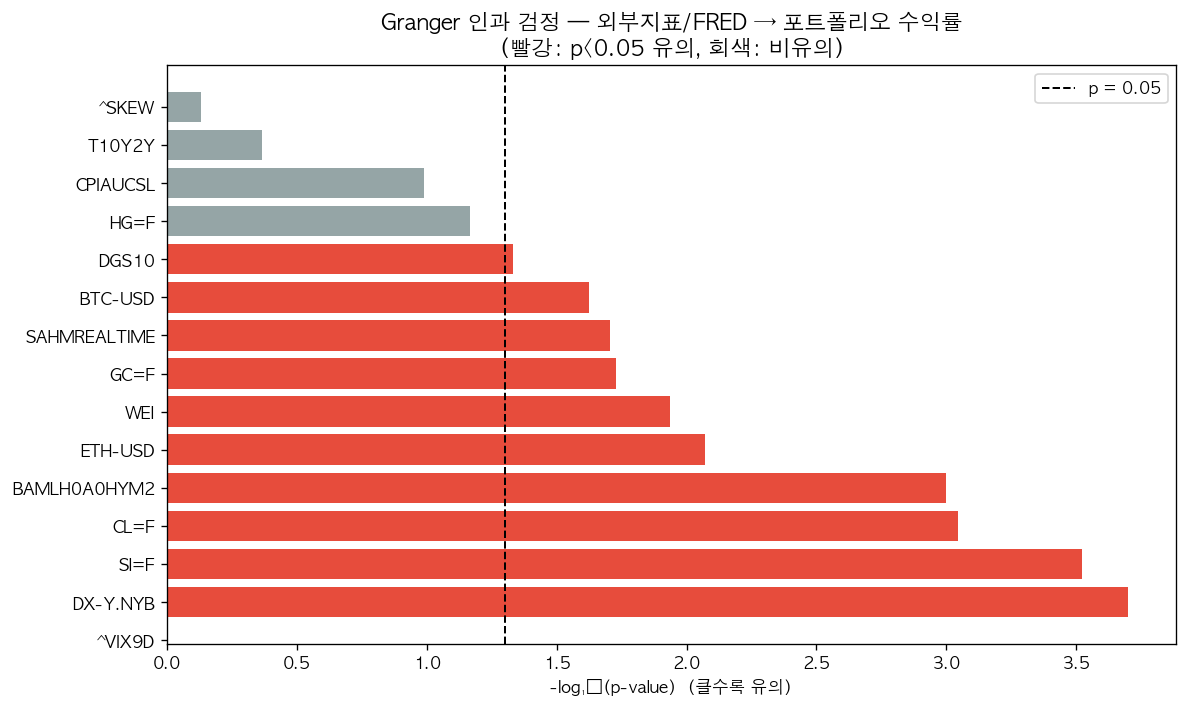

In [51]:
# ── Granger 인과 검정 ─────────────────────────────────────────
from statsmodels.tsa.stattools import grangercausalitytests

# 등가중 포트폴리오 수익률 (타겟 Y)
port_ew = port_final.mean(axis=1)
port_ew.name = 'port_ew'

def run_granger(target, predictors, max_lag=5, alpha=0.05):
    results = []
    for col in predictors.columns:
        df_pair = pd.concat([target, predictors[col]], axis=1).dropna()
        df_pair.columns = ['target', 'predictor']
        try:
            test = grangercausalitytests(df_pair, maxlag=max_lag, verbose=False)
            for lag in range(1, max_lag + 1):
                p_val = test[lag][0]['ssr_ftest'][1]
                results.append({
                    'predictor': col,
                    'lag': lag,
                    'p_value': round(p_val, 4),
                    'significant': '유의' if p_val < alpha else '-'
                })
        except Exception:
            pass
    return pd.DataFrame(results)

# 외부지표 + FRED → 포트폴리오 수익률
predictors = pd.concat([ext_final, fred_final], axis=1)
granger_df = run_granger(port_ew, predictors, max_lag=5)

# 유의한 결과 출력
sig = granger_df[granger_df['significant'] == '유의'].sort_values('p_value')
print(f'유의한 Granger 인과 쌍 (p<0.05): {len(sig)}개')
display(sig.reset_index(drop=True))

# 변수별 최소 p-value (가장 유의한 시차 기준) 시각화
best = granger_df.groupby('predictor')['p_value'].min().reset_index()
best = best.sort_values('p_value').reset_index(drop=True)
best['sig'] = best['p_value'] < 0.05

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if s else '#95a5a6' for s in best['sig']]
ax.barh(best['predictor'], -np.log10(best['p_value']), color=colors)
ax.axvline(-np.log10(0.05), color='black', linestyle='--', linewidth=1.2, label='p = 0.05')
ax.set_xlabel('-log₁₀(p-value)  (클수록 유의)')
ax.set_title('Granger 인과 검정 — 외부지표/FRED → 포트폴리오 수익률\n(빨강: p<0.05 유의, 회색: 비유의)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()


#### Granger 검정 결과 해석

##### 검정 방법
- **타겟(Y)**: 포트폴리오 30개 자산의 등가중 수익률
- **예측변수(X)**: 외부지표 + FRED (정상화된 변수)
- **시차(lag)**: 1~5일, 각 변수의 최소 p-value 기준으로 판단
- **판단 기준**: p < 0.05 → X의 과거값이 Y 예측에 유의미한 정보 추가

---

##### 유의한 변수 (빨강, p < 0.05)

| 변수 | 의미 | 해석 |
|------|------|------|
| **DX-Y.NYB** | 달러 인덱스 | 달러 강세/약세가 시차를 두고 포트폴리오 전반에 영향 → 글로벌 자산에 공통 요인 |
| **SI=F** | 은 | 원자재 가격 변화가 포트폴리오 수익률 예측에 유의 |
| **CL=F** | 원유 | 에너지 가격이 경기·기업실적 경로로 수익률에 선행 |
| **BAMLH0A0HYM2** | 하이일드 스프레드 | 신용위험 확대 신호가 주가에 시차를 두고 반영 → 리스크 관리 핵심 지표 |
| **ETH-USD / BTC-USD** | 암호화폐 | 위험선호 지표로 작동, 최근 전통 자산과 연동 강화 |
| **WEI** | 주간경제지수 | 실시간 경기 모멘텀이 수익률에 선행 |
| **GC=F** | 금 | 안전자산 수요 변화가 포트폴리오에 선행 신호 |
| **SAHMREALTIME** | Sahm 경기침체 지표 | 경기침체 신호가 수익률 하락에 선행 |
| **DGS10** | 10년 국채금리 | 금리 변화가 할인율 경로로 주가에 시차 영향 |

##### 비유의한 변수 (회색, p ≥ 0.05)

| 변수 | 의미 | 해석 |
|------|------|------|
| **^VIX9D** | 단기 공포지수 | 현재값은 중요하지만 **과거값이 추가 정보를 제공하지 않음** → 동행지표에 가까움 |
| **^SKEW** | 꼬리 위험 지수 | 극단적 하락 위험 측정, 단기 수익률 예측력은 낮음 |
| **T10Y2Y** | 장단기 금리 스프레드 | 장기 경기 예측 지표, 단기 수익률 예측에는 시차가 너무 김 |
| **CPIAUCSL** | 소비자물가지수 | 월별 지표로 일별 수익률 예측에 한계 |
| **HG=F** | 구리 | 경기선행지표이나 이 포트폴리오 구성에서는 유의하지 않음 |

---

> **핵심**: 달러, 원자재(금·은·원유), 신용스프레드, 암호화폐가 포트폴리오 수익률에 선행하는 신호를 가짐  
> VIX는 **동행지표** 성격 → 현재 리스크 수준 파악에는 유용하지만 Granger 선행성은 약함

### 5-1. Granger 보완

**① 희소 데이터 확인**  
FRED 변수는 주간·월간 단위로 발표되지만 일별 데이터로 변환 시 forward-fill(이전 값 유지)됨  
→ 차분하면 발표일만 값이 존재하고 나머지는 전부 0  
→ Granger 검정이 '0의 패턴'에 반응해 잘못된 유의성을 보고할 수 있음

**② AIC 최적 Lag 선택**  
이전 방식(lag 1~5 중 최솟값)은 5번 테스트 후 가장 좋은 결과만 고르는 것 → 다중검정 문제  
→ VAR 모델의 AIC 기준으로 각 변수에 맞는 최적 lag를 먼저 찾고, 그 lag에서만 검정  
→ 결과의 신뢰도가 더 높아짐

=== FRED 변수 희소성 확인 (차분 후 0 비율) ===


,variable,0 비율,판정
5,CPIAUCSL,0.9548,희소 주의
7,T10Y2Y,0.1852,양호
3,SAHMREALTIME,0.1415,양호
6,DGS10,0.1258,양호
0,BAMLH0A0HYM2,0.0000,양호
1,ICSA,0.0000,양호
2,WEI,0.0000,양호
4,UNRATE,0.0000,양호



=== AIC 최적 Lag 기반 Granger 재검정 ===
희소 변수 제외: ['CPIAUCSL']


,predictor,best_lag(AIC),p_value,significant
0,^VIX,10,0.0000,유의
1,^VIX9D,9,0.0000,유의
2,^VIX3M,10,0.0000,유의
3,^VIX6M,10,0.0000,유의
4,UNRATE,10,0.0000,유의
5,SAHMREALTIME,10,0.0000,유의
6,ICSA,10,0.0000,유의
7,BAMLH0A0HYM2,10,0.0000,유의
8,CL=F,10,0.0006,유의
9,DX-Y.NYB,9,0.0027,유의


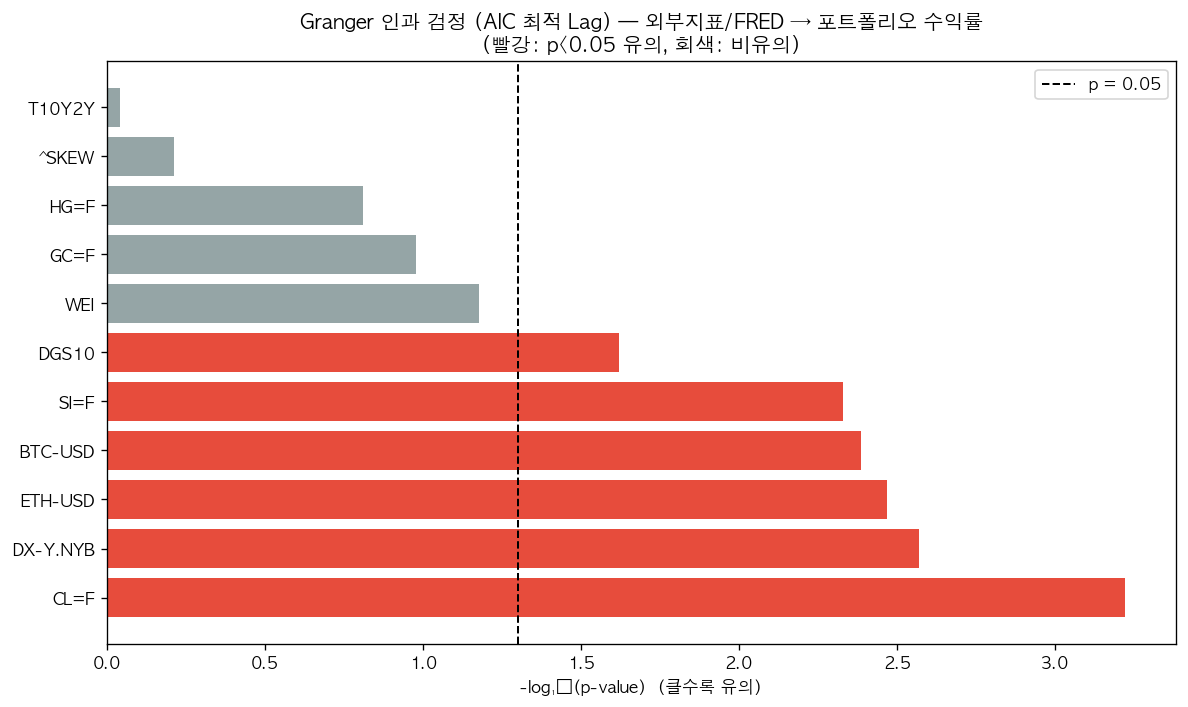

In [54]:
# ── Granger 보완 ──────────────────────────────────────────────
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.vector_ar.var_model import VAR

# 1. 희소성 확인 (차분 후 0 비율)
print('=== FRED 변수 희소성 확인 (차분 후 0 비율) ===')
sparse_result = []
for col in fred_final.columns:
    zero_ratio = (fred_final[col] == 0).mean()
    sparse_result.append({
        'variable': col,
        '0 비율': round(zero_ratio, 4),
        '판정': '희소 주의' if zero_ratio > 0.5 else '양호'
    })
display(pd.DataFrame(sparse_result).sort_values('0 비율', ascending=False))

# 2. AIC 기준 최적 lag 선택 후 Granger 재검정
print('\n=== AIC 최적 Lag 기반 Granger 재검정 ===')

def run_granger_aic(target, predictors, max_lag=10, alpha=0.05):
    results = []
    for col in predictors.columns:
        df_pair = pd.concat([target, predictors[col]], axis=1).dropna()
        df_pair.columns = ['target', 'predictor']
        try:
            # AIC로 최적 lag 탐색
            var_model = VAR(df_pair)
            lag_order = var_model.select_order(maxlags=max_lag)
            best_lag = lag_order.aic
            best_lag = max(1, best_lag)  # 최소 1

            # 최적 lag로 Granger 검정
            test = grangercausalitytests(df_pair, maxlag=best_lag, verbose=False)
            p_val = test[best_lag][0]['ssr_ftest'][1]
            results.append({
                'predictor': col,
                'best_lag(AIC)': best_lag,
                'p_value': round(p_val, 4),
                'significant': '유의' if p_val < alpha else '-'
            })
        except Exception:
            pass
    result_df = pd.DataFrame(results).sort_values('p_value')
    return result_df

# 희소 변수 제외 후 검정 (0 비율 > 0.5)
sparse_cols = [r['variable'] for r in sparse_result if r['판정'] == '희소 주의']
if sparse_cols:
    print(f'희소 변수 제외: {sparse_cols}')
predictors_clean = pd.concat([
    ext_final,
    fred_final.drop(columns=sparse_cols, errors='ignore')
], axis=1)

granger_aic = run_granger_aic(port_ew, predictors_clean, max_lag=10)
display(granger_aic.reset_index(drop=True))

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if s == '유의' else '#95a5a6' for s in granger_aic['significant']]
ax.barh(granger_aic['predictor'], -np.log10(granger_aic['p_value']), color=colors)
ax.axvline(-np.log10(0.05), color='black', linestyle='--', linewidth=1.2, label='p = 0.05')
ax.set_xlabel('-log₁₀(p-value)  (클수록 유의)')
ax.set_title('Granger 인과 검정 (AIC 최적 Lag) — 외부지표/FRED → 포트폴리오 수익률\n(빨강: p<0.05 유의, 회색: 비유의)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()


#### Granger 보완 결과 해석


##### [ 희소성 확인 결과 ]

| 변수 | 0 비율 | 조치 |
|------|--------|------|
| **CPIAUCSL** | **95.5%** | **Granger 검정에서 제외** — 월별 발표로 일별 차분 시 거의 전부 0 |
| T10Y2Y | 18.5% | 유지 — 허용 범위 |
| SAHMREALTIME | 14.2% | 유지 |
| 나머지 | 0% | 이상 없음 |

---

##### [ AIC Granger 재검정 결과 ] — 이전과 달라진 점

**최적 lag가 대부분 9~10일** → 약 2주 시차에서 관계가 뚜렷하게 나타남

| 변화 | 변수 | 해석 |
|------|------|------|
| 비유의 → **유의** | `^VIX`, `^VIX3M`, `^VIX6M`, `^VIX9D` | 짧은 lag(1~5일)에선 안 보이던 관계가 lag 9~10에서 나타남 → VIX 영향은 **약 2주 시차** |
| 유의 → **비유의** | `GC=F` (금) | 단기 lag에서만 유의, 긴 시차에서는 예측력 없음 |
| 유의 → **경계선** | `WEI` | p=0.066, 주간 발표 특성상 노이즈 가능성 |
| **제외** | `CPIAUCSL` | 희소 데이터로 검정 자체가 불신뢰 |

---

##### Granger 기준 유의 변수 (p < 0.05)

> ⚠️ **Granger 인과 검정 결과만 반영** — VIF 다중공선성 기준과 교차 적용 및 파생변수 생성은 별도 진행

| 그룹 | 유의 변수 |
|------|----------|
| VIX 계열 | `^VIX`, `^VIX3M`, `^VIX6M`, `^VIX9D` |
| 외부지표 | `CL=F`, `DX-Y.NYB`, `ETH-USD`, `BTC-USD`, `SI=F`, `DGS10` |
| FRED | `UNRATE`, `SAHMREALTIME`, `ICSA`, `BAMLH0A0HYM2` |

| 그룹 | 비유의 변수 |
|------|-------------|
| 외부지표 | `GC=F`, `HG=F`, `^SKEW` |
| FRED | `WEI`(경계선), `T10Y2Y`, `CPIAUCSL`(희소 제외) |


### 변수 선정 기준 정리

| 기준 | 역할 |
|------|------|
| **Granger 유의** | 예측력 있는 변수 선별 |
| **VIF 양호** | 다중공선성 없는 변수 선별 |
| **둘 다 통과** | 진짜 최종 예측변수 |

### 6. ARCH 효과 검정

**변동성 군집(Volatility Clustering)**: 큰 변동이 있던 날 다음엔 또 큰 변동이, 작은 변동이 있던 날 다음엔 작은 변동이 이어지는 현상

- **왜 확인하는가**: ARCH 효과가 있으면 잔차 분산이 일정하지 않음(이분산성) → OLS 가정 위반 → GARCH 계열 모델 필요
- **검정 방법**:
  - 수익률 제곱의 ACF/PACF 시각화 → 자기상관 있으면 변동성 군집 존재
  - **Engle's ARCH LM Test**: 귀무가설 = ARCH 효과 없음, p < 0.05 → ARCH 효과 존재

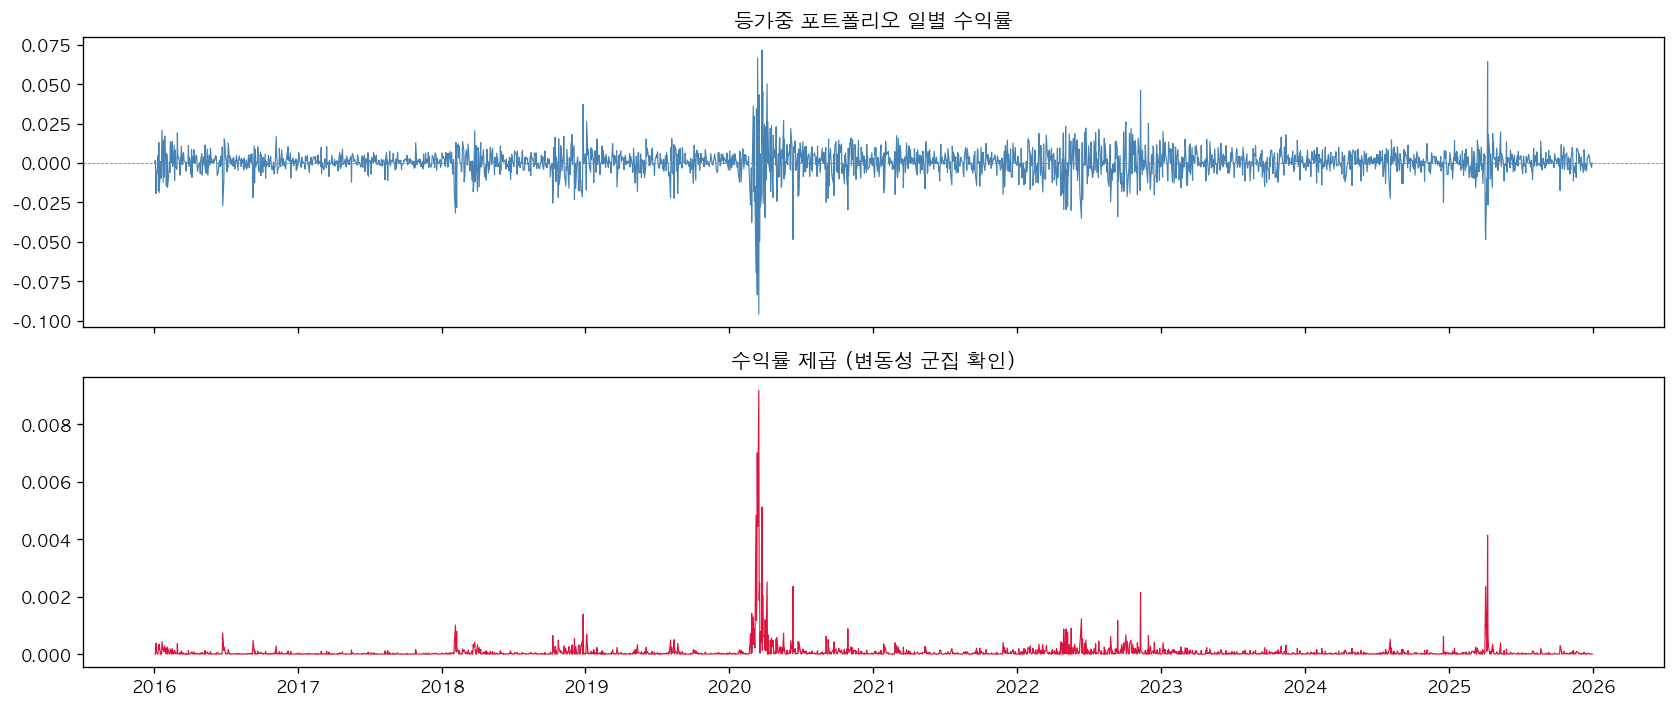

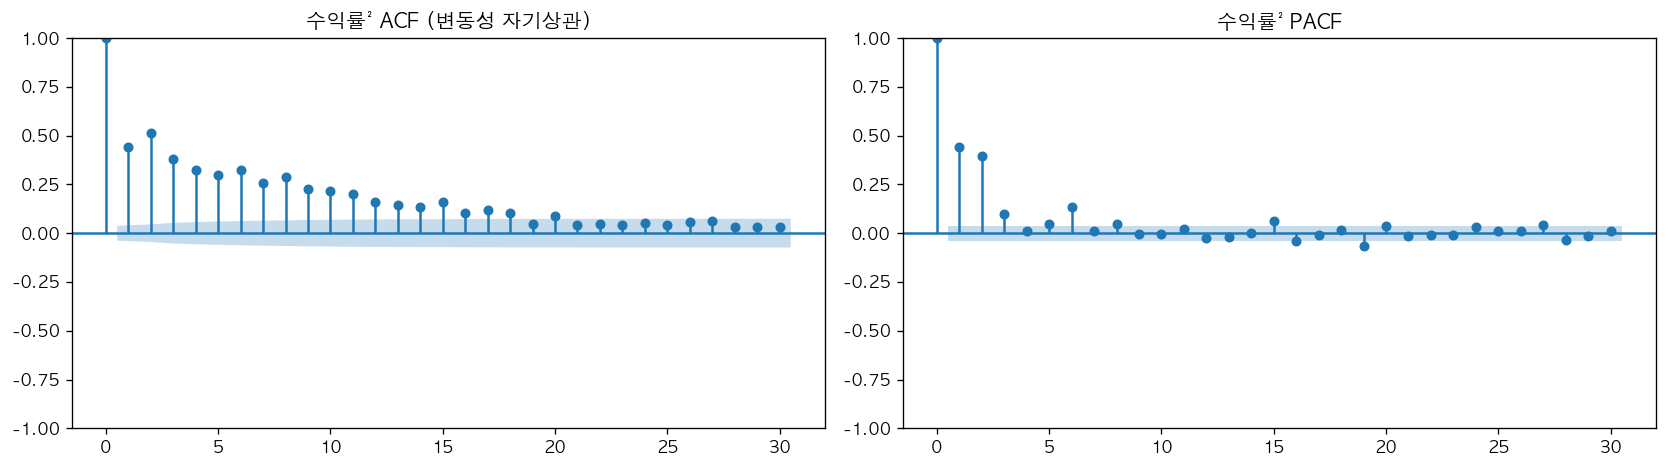

=== Engle ARCH LM Test ===


,lag,LM_stat,p_value,ARCH 효과
0,5,857.9667,0.0,YES ✓
1,10,891.9204,0.0,YES ✓
2,20,911.8059,0.0,YES ✓


In [55]:
# ── ARCH 효과 검정 ────────────────────────────────────────────
from statsmodels.stats.diagnostic import het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 등가중 포트폴리오 수익률 (port_ew는 앞에서 정의됨)
ret = port_ew.dropna()
ret_sq = ret ** 2  # 수익률 제곱 → 변동성 대리변수

# 1. 수익률 & 수익률 제곱 시계열
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(ret.index, ret.values, lw=0.7, color='steelblue')
axes[0].set_title('등가중 포트폴리오 일별 수익률', fontweight='bold')
axes[0].axhline(0, color='gray', lw=0.5, ls='--')
axes[1].plot(ret_sq.index, ret_sq.values, lw=0.7, color='crimson')
axes[1].set_title('수익률 제곱 (변동성 군집 확인)', fontweight='bold')
plt.tight_layout()
plt.show()

# 2. 수익률 제곱의 ACF / PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(ret_sq, lags=30, ax=axes[0], title='수익률² ACF (변동성 자기상관)')
plot_pacf(ret_sq, lags=30, ax=axes[1], title='수익률² PACF')
plt.tight_layout()
plt.show()

# 3. Engle's ARCH LM Test
print('=== Engle ARCH LM Test ===')
lm_results = []
for lag in [5, 10, 20]:
    lm_stat, p_val, f_stat, f_p = het_arch(ret, nlags=lag)
    lm_results.append({
        'lag': lag,
        'LM_stat': round(lm_stat, 4),
        'p_value': round(p_val, 4),
        'ARCH 효과': 'YES ✓' if p_val < 0.05 else 'NO'
    })
display(pd.DataFrame(lm_results))


#### ARCH 효과 검정 결과 해석

##### Engle ARCH LM Test 결과

| lag | LM_stat | p_value | 판정 |
|-----|---------|---------|------|
| 5  | 857.97 | 0.0000 | ARCH 효과 존재 ✓ |
| 10 | 891.92 | 0.0000 | ARCH 효과 존재 ✓ |
| 20 | 911.81 | 0.0000 | ARCH 효과 존재 ✓ |

**세 lag 모두 p=0.000, LM 통계량 800~900대** → ARCH 효과 매우 강하게 존재

---

##### 해석

**① 변동성 군집 확인**  
수익률 제곱의 ACF에서 여러 lag에 걸쳐 유의한 자기상관 → 큰 변동 뒤엔 큰 변동, 작은 변동 뒤엔 작은 변동이 이어지는 패턴이 뚜렷

**② OLS 가정 위반**  
잔차 분산이 시간에 따라 변함(이분산성) → 단순 OLS/선형회귀로 변동성을 예측하면 추정치가 비효율적

**③ 모델 선택 근거**  
- 변동성 예측(rv_neutral)이 목표 → **GARCH 계열 모델 사용 권장**
- 포트폴리오 최적화 시 공분산 추정에도 GARCH 기반 동적 공분산 행렬 활용 가능

> **결론**: ARCH 효과가 통계적으로 매우 강하게 확인됨 → Step 5 리스크 분석에서 GARCH 모델 도입 근거 마련